## A Prototype Application for Machine Learning-Based Anomaly Detection in Well Log Data

#### Import necessary libraries

In [135]:
# Import necessary libraries
import os
import lasio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt
from fpdf import FPDF
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from matplotlib.backends.backend_pdf import PdfPages
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import regularizers
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import argparse
import warnings
warnings.filterwarnings("ignore")



In [136]:
las_folder = r"C:\Users\LENOVO\Downloads\SASTRA PROJECT\WELL DATA\New Data"
las_files = glob.glob(os.path.join(las_folder, "*.las"))

print(las_files)

['C:\\Users\\LENOVO\\Downloads\\SASTRA PROJECT\\WELL DATA\\New Data\\1.las',
 'C:\\Users\\LENOVO\\Downloads\\SASTRA PROJECT\\WELL DATA\\New Data\\2.las',
 'C:\\Users\\LENOVO\\Downloads\\SASTRA PROJECT\\WELL DATA\\New Data\\3.las',
 'C:\\Users\\LENOVO\\Downloads\\SASTRA PROJECT\\WELL DATA\\New Data\\4.las']


['C:\\Users\\LENOVO\\Downloads\\SASTRA PROJECT\\WELL DATA\\New Data\\1.las', 'C:\\Users\\LENOVO\\Downloads\\SASTRA PROJECT\\WELL DATA\\New Data\\2.las', 'C:\\Users\\LENOVO\\Downloads\\SASTRA PROJECT\\WELL DATA\\New Data\\3.las', 'C:\\Users\\LENOVO\\Downloads\\SASTRA PROJECT\\WELL DATA\\New Data\\4.las']


['C:\\Users\\LENOVO\\Downloads\\SASTRA PROJECT\\WELL DATA\\New Data\\1.las',
 'C:\\Users\\LENOVO\\Downloads\\SASTRA PROJECT\\WELL DATA\\New Data\\2.las',
 'C:\\Users\\LENOVO\\Downloads\\SASTRA PROJECT\\WELL DATA\\New Data\\3.las',
 'C:\\Users\\LENOVO\\Downloads\\SASTRA PROJECT\\WELL DATA\\New Data\\4.las']

In [137]:
# Load them into DataFrames
well_dfs = []

for file in las_files:
    las = lasio.read(file)
    df = las.df() 
    df.reset_index(inplace=True)
    df.rename(columns={'DEPTH': 'DEPT'}, inplace=True, errors='ignore')

    well_name = os.path.basename(file).replace('.las', '')
    df["Well"] = f"Well {well_name}"
    well_dfs.append(df)

# Display the first few rows of the first well as a sample
print(well_dfs[0].info())
print(well_dfs[1].info())
print(well_dfs[2].info())
print(well_dfs[3].info())

# File paths for the LAS files
Well_1 = las_files[0]
Well_2 = las_files[1]
Well_3 = las_files[2]
Well_4 = las_files[3]
print(Well_1)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1125 entries, 0 to 1124
Data columns (total 22 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DEPT    1125 non-null   float64
 1   CFTC    1058 non-null   float64
 2   CNTC    1058 non-null   float64
 3   SP      1085 non-null   float64
 4   CALD    1072 non-null   float64
 5   CALN    1053 non-null   float64
 6   GR      1042 non-null   float64
 7   LWTLB   1085 non-null   float64
 8   DRHO    1077 non-null   float64
 9   SFL     1085 non-null   float64
 10  CILD    1085 non-null   float64
 11  RHOB    1077 non-null   float64
 12  NPDL    1053 non-null   float64
 13  NPLS    1053 non-null   float64
 14  NPSS    1053 non-null   float64
 15  PE      1077 non-null   float64
 16  ILM     1083 non-null   float64
 17  ILD     1085 non-null   float64
 18  DPDL    1077 non-null   float64
 19  DPLS    1077 non-null   float64
 20  DPSS    1077 non-null   float64
 21  Well    1125 non-null   object 
dtype

In [138]:
# Data Cleaning and Preprocessing for Well 1
Df1 = lasio.read(Well_1)
df1 = Df1.df().reset_index()   
df1.columns = df1.columns.str.upper()
features = ['DEPT', 'GR', 'RHOB', 'ILD', 'SP', 'CALD', 'DRHO']
available = [col for col in features if col in df1.columns]
missing = [col for col in features if col not in df1.columns]
print(f"Available features in Well 1: {available}")
print(f"Missing features in Well 1: {missing}")

Df2 = lasio.read(Well_2)
df2 = Df2.df().reset_index()
df2.columns = df2.columns.str.upper()
features = ['DEPT', 'GR', 'RHOB', 'ILD', 'SP', 'CALD', 'DRHO']
available = [col for col in features if col in df2.columns]
missing = [col for col in features if col not in df2.columns]
print(f"Available features in Well 2: {available}")
print(f"Missing features in Well 2: {missing}")

Df3 = lasio.read(Well_3)
df3 = Df3.df().reset_index()
df3.columns = df3.columns.str.upper()
features = ['DEPT', 'GR', 'RHOB', 'ILD', 'SP', 'CALD', 'DRHO']
available = [col for col in features if col in df3.columns]
missing = [col for col in features if col not in df3.columns]
print(f"Available features in Well 3: {available}")
print(f"Missing features in Well 3: {missing}")

Df4 = lasio.read(Well_4)
df4 = Df4.df().reset_index()
df4.columns = df4.columns.str.upper()
features = ['DEPT', 'GR', 'RHOB', 'ILD', 'SP', 'CALD', 'DRHO']
available = [col for col in features if col in df4.columns]
missing = [col for col in features if col not in df4.columns]
print(f"Available features in Well 4: {available}")
print(f"Missing features in Well 4: {missing}")


# Data Cleaning Function
def clean_well_data(df, features):
    # Select only the relevant features
    df_selected = df[features].copy()
    
    # Remove rows with all NaNs in the selected features
    df_clean = df_selected.dropna(how='all', subset=features[1:])  # Exclude 'DEPT' from 'all' check
    
    # Impute missing values with the mean of each column
    imputer = SimpleImputer(strategy='mean')
    df_clean[features[1:]] = imputer.fit_transform(df_clean[features[1:]])
    
    return df_selected, df_clean
# Clean data for each well
features = ['DEPT', 'GR', 'RHOB', 'ILD', 'SP', 'CALD', 'DRHO']
df1_selected, df1_clean = clean_well_data(df1, features)
df2_selected, df2_clean = clean_well_data(df2, features)
df3_selected, df3_clean = clean_well_data(df3, features)
df4_selected, df4_clean = clean_well_data(df4, features)

# Display the number of rows before and after cleaning for each well
print(f"Well 1: Original Rows = {len(df1_selected)}, Cleaned Rows = {len(df1_clean)}")
print(f"Well 2: Original Rows = {len(df2_selected)}, Cleaned Rows = {len(df2_clean)}")
print(f"Well 3: Original Rows = {len(df3_selected)}, Cleaned Rows = {len(df3_clean)}")
print(f"Well 4: Original Rows = {len(df4_selected)}, Cleaned Rows = {len(df4_clean)}")


Available features in Well 1: ['DEPT', 'GR', 'RHOB', 'ILD', 'SP', 'CALD', 'DRHO']
Missing features in Well 1: []
Available features in Well 2: ['DEPT', 'GR', 'RHOB', 'ILD', 'SP', 'CALD', 'DRHO']
Missing features in Well 2: []
Available features in Well 3: ['DEPT', 'GR', 'RHOB', 'ILD', 'SP', 'CALD', 'DRHO']
Missing features in Well 3: []
Available features in Well 4: ['DEPT', 'GR', 'RHOB', 'ILD', 'SP', 'CALD', 'DRHO']
Missing features in Well 4: []
Well 1: Original Rows = 1125, Cleaned Rows = 1122
Well 2: Original Rows = 1085, Cleaned Rows = 1081
Well 3: Original Rows = 1002, Cleaned Rows = 998
Well 4: Original Rows = 1200, Cleaned Rows = 1196


In [139]:
# Standardize the data
scaler = StandardScaler()
def scale_well_data(df_clean, scaler):
    df_scaled = df_clean.copy()
    df_scaled[df_clean.columns[1:]] = scaler.fit_transform(df_clean[df_clean.columns[1:]])
    return df_scaled
df1_scaled = scale_well_data(df1_clean, scaler)
df2_scaled = scale_well_data(df2_clean, scaler)
df3_scaled = scale_well_data(df3_clean, scaler)
df4_scaled = scale_well_data(df4_clean, scaler)

# Display the head of scaled data for verification before and after scaling
print("=== Summary of Scaling ===")
print("Well 1: Mean (before) = {:.4f}, Std (before) = {:.4f}".format(
    df1_clean.drop(columns=['DEPT']).mean().mean(),
    df1_clean.drop(columns=['DEPT']).std().mean()
))

print("Well 1: Mean (after) = {:.4f}, Std (after) = {:.4f}".format(
    df1_scaled.drop(columns=['DEPT']).mean().mean(),
    df1_scaled.drop(columns=['DEPT']).std().mean()
))


print("=== Standard Deviation Before Scaling ===")
print(df1_clean.drop(columns=['DEPT']).std())

print("\n=== Standard Deviation After Scaling ===")
print(df1_scaled.drop(columns=['DEPT']).std())



=== Summary of Scaling ===
Well 1: Mean (before) = 16.5296, Std (before) = 171.8196
Well 1: Mean (after) = 0.0000, Std (after) = 1.0004
=== Standard Deviation Before Scaling ===
GR       45.773773
RHOB      0.176502
ILD     938.682072
SP       45.353512
CALD      0.848871
DRHO      0.082949
dtype: float64

=== Standard Deviation After Scaling ===
GR      1.000446
RHOB    1.000446
ILD     1.000446
SP      1.000446
CALD    1.000446
DRHO    1.000446
dtype: float64


In [140]:
# Isolation Forest Anomaly Detection

wells_scaled = {
    "Well_1": df1_scaled.copy(),
    "Well_2": df2_scaled.copy(),
    "Well_3": df3_scaled.copy(),
    "Well_4": df4_scaled.copy()
}

# Define anomaly detection function
def detect_anomalies(df_scaled, well_name, contamination=0.02, threshold_percentile=95):
    print(f"\n=== Processing {well_name} ===")
    
    # Prepare features (exclude DEPT)
    X = df_scaled.drop(columns=['DEPT']).values

    # === Isolation Forest ===
    iso = IsolationForest(contamination=contamination, random_state=42)
    iso_labels = iso.fit_predict(X)
    df_scaled['IF_Anomaly'] = np.where(iso_labels == -1, 1, 0)
    print(f"Isolation Forest anomalies: {df_scaled['IF_Anomaly'].sum()}")
    return df_scaled

df1_scaled = detect_anomalies(df1_scaled, "Well_1")
df2_scaled = detect_anomalies(df2_scaled, "Well_2")
df3_scaled = detect_anomalies(df3_scaled, "Well_3")
df4_scaled = detect_anomalies(df4_scaled, "Well_4")

wells_anomalies = {
    "Well_1": df1_scaled,
    "Well_2": df2_scaled,
    "Well_3": df3_scaled,
    "Well_4": df4_scaled
}

for name, df in wells_anomalies.items():
    total = len(df)
    anomalies = df['IF_Anomaly'].sum()
    print(f"{name}: {anomalies} anomalies ({anomalies/total*100:.2f}%)")



=== Processing Well_1 ===
Isolation Forest anomalies: 23

=== Processing Well_2 ===
Isolation Forest anomalies: 22

=== Processing Well_3 ===
Isolation Forest anomalies: 20

=== Processing Well_4 ===
Isolation Forest anomalies: 24
Well_1: 23 anomalies (2.05%)
Well_2: 22 anomalies (2.04%)
Well_3: 20 anomalies (2.00%)
Well_4: 24 anomalies (2.01%)



=== Plotting Well_1 ===


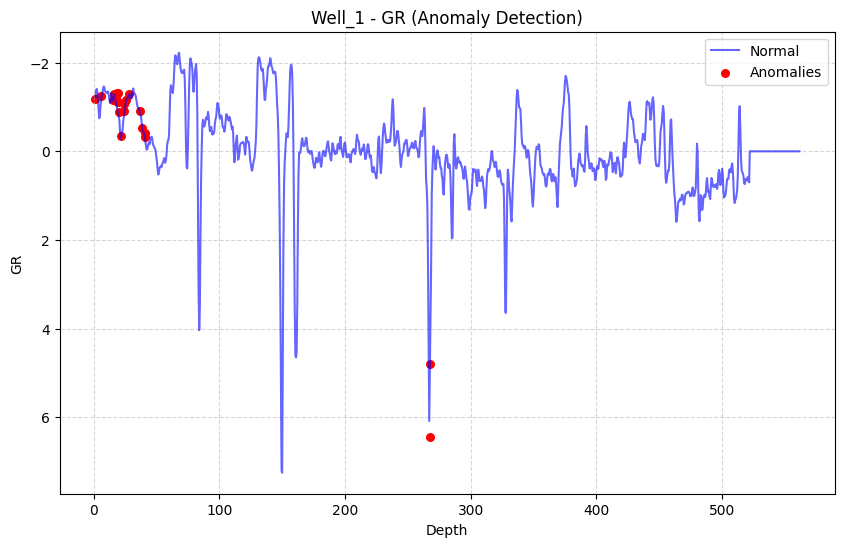

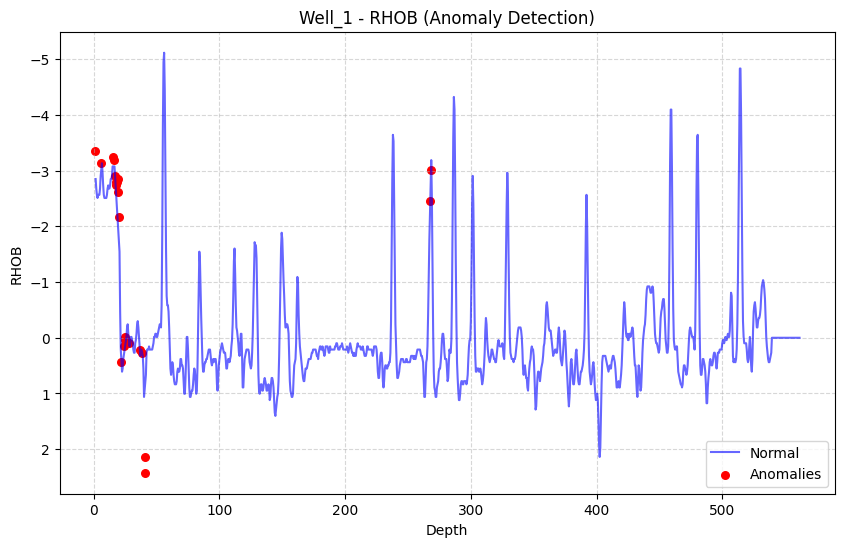

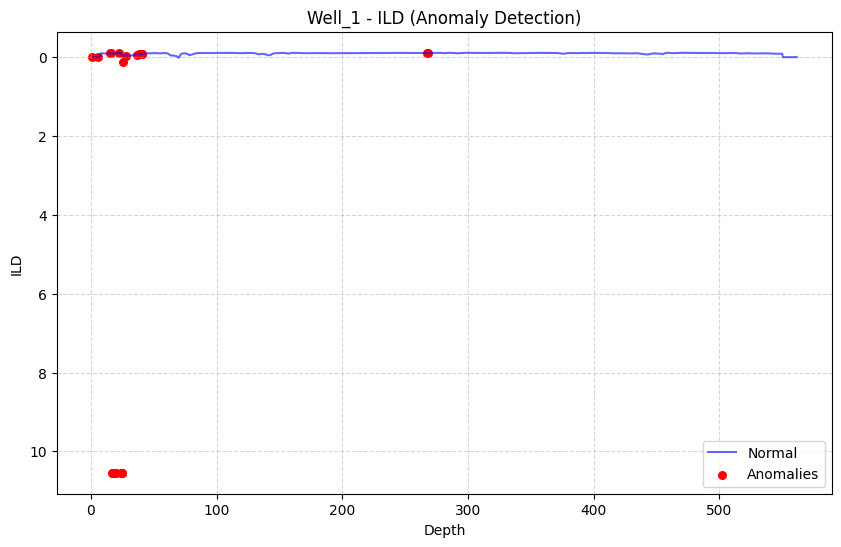

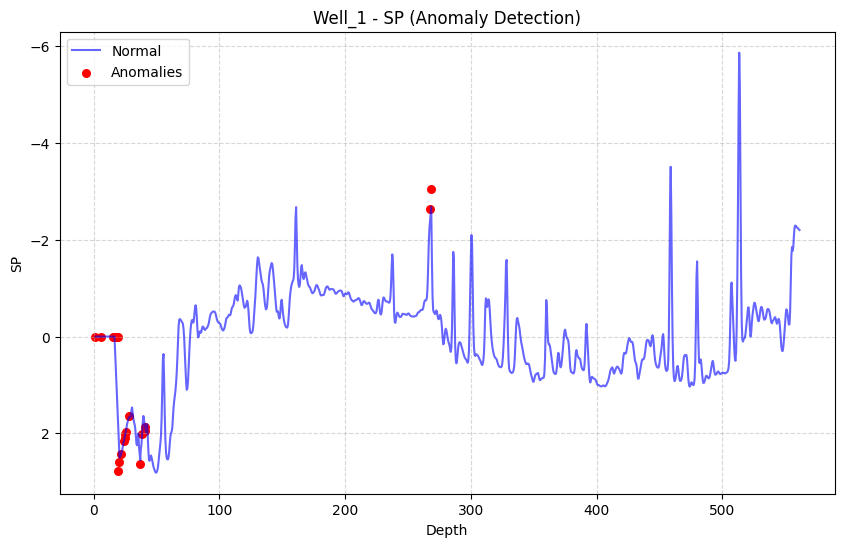

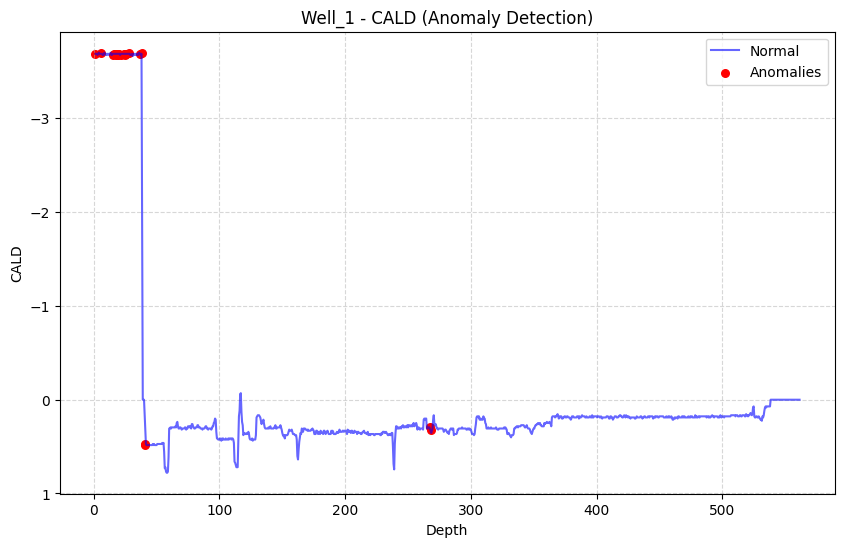

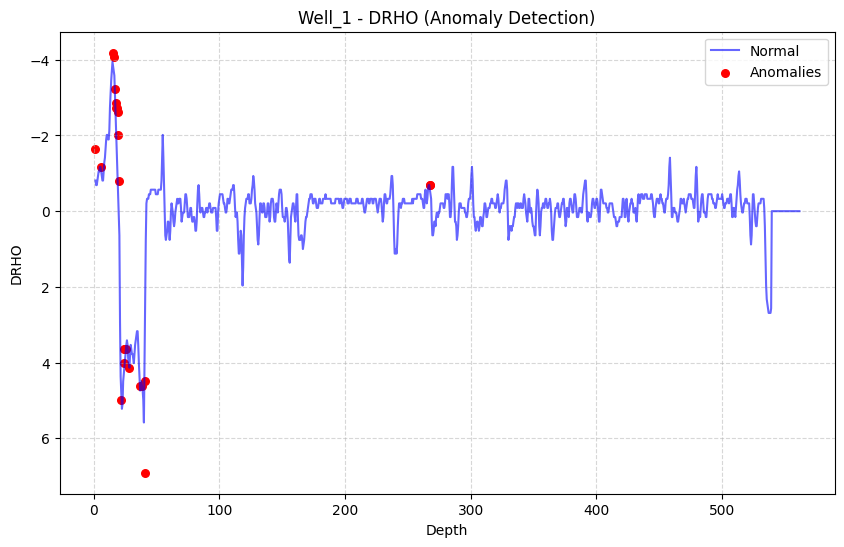


=== Plotting Well_2 ===


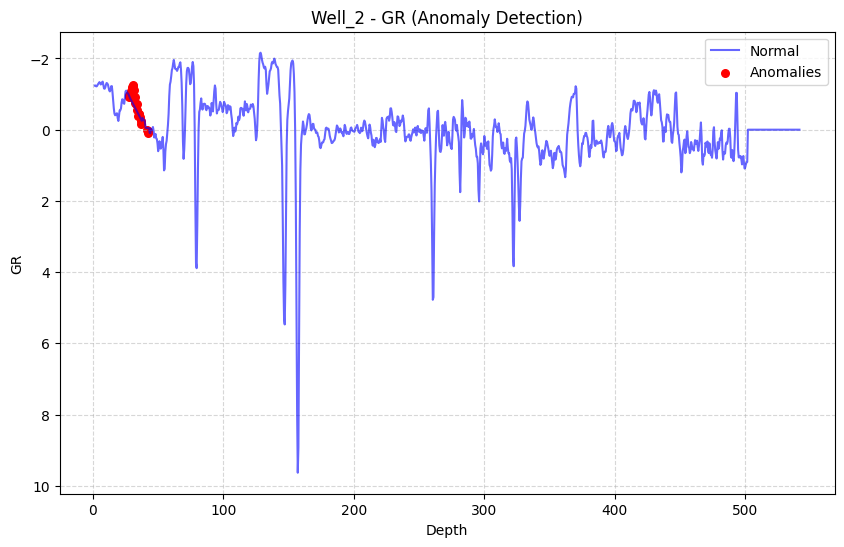

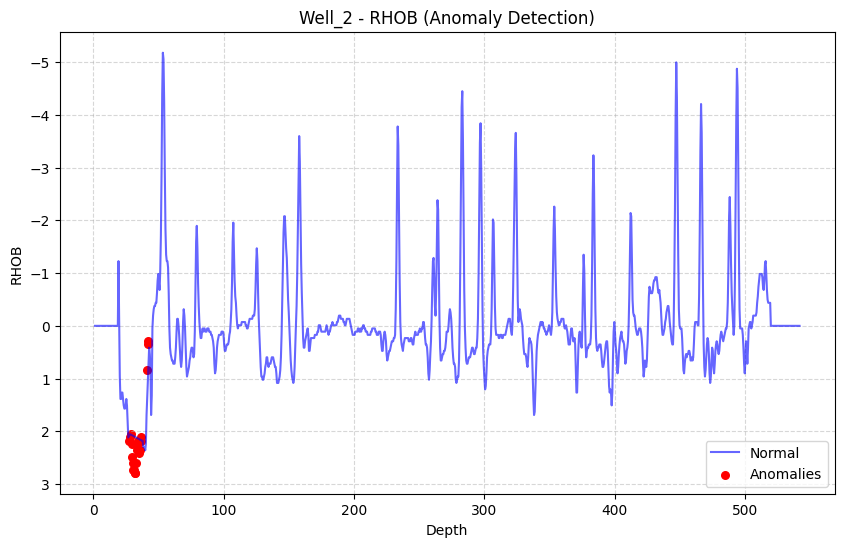

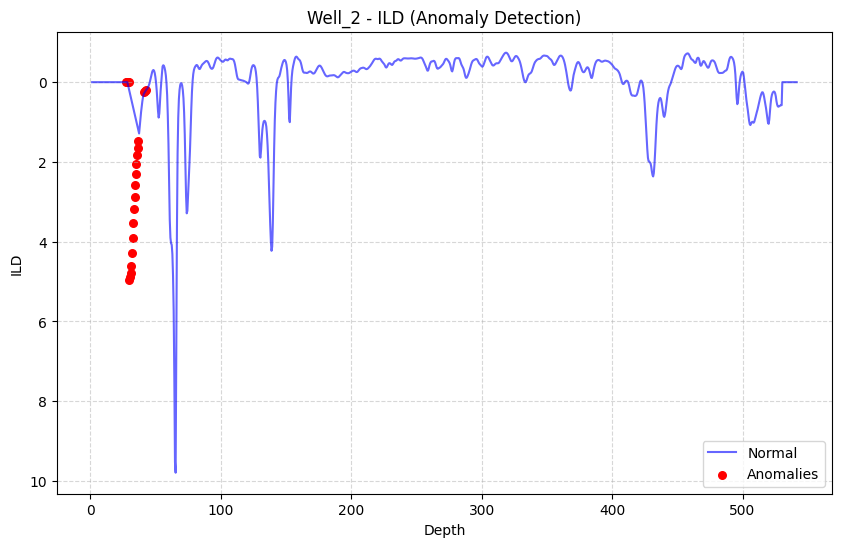

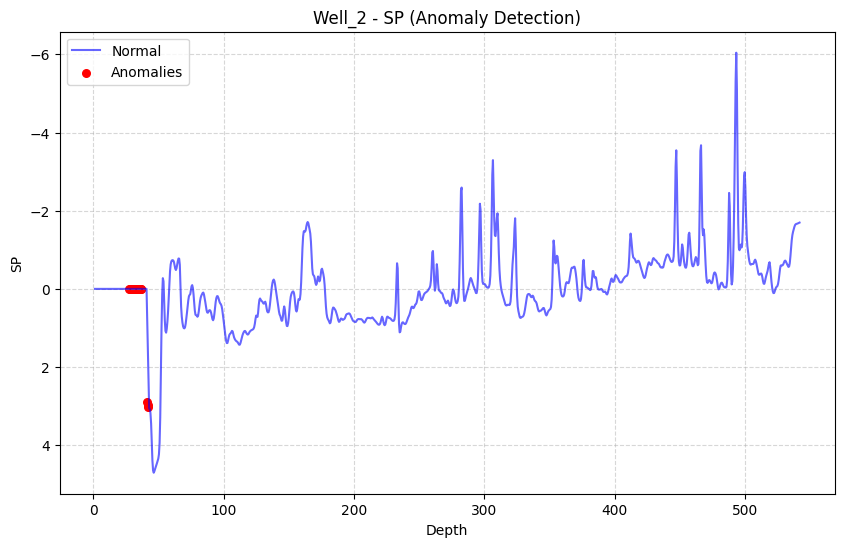

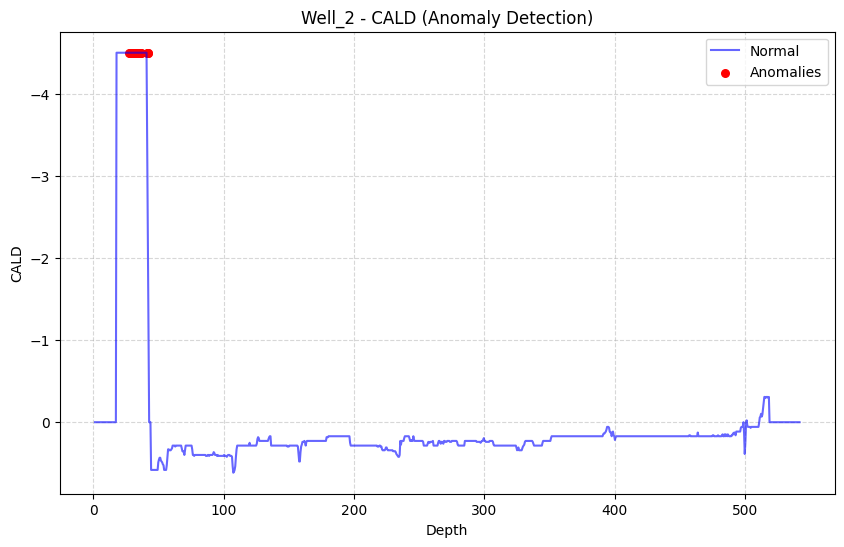

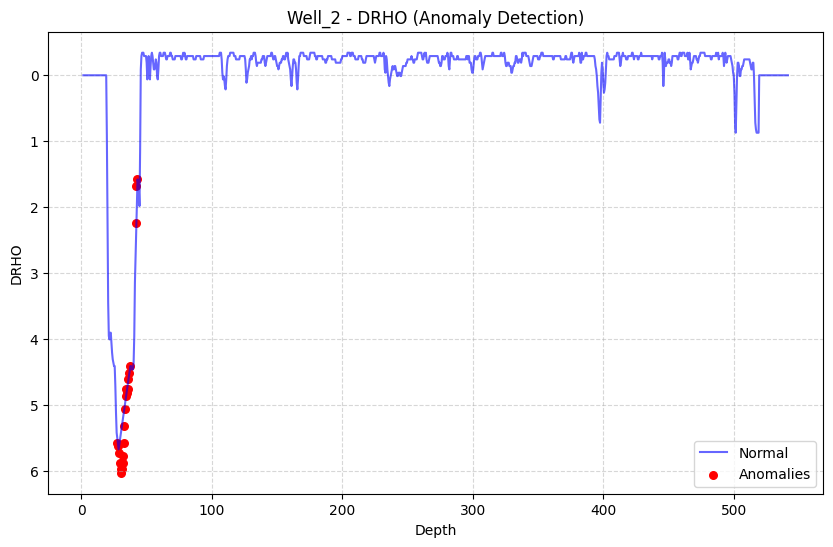


=== Plotting Well_3 ===


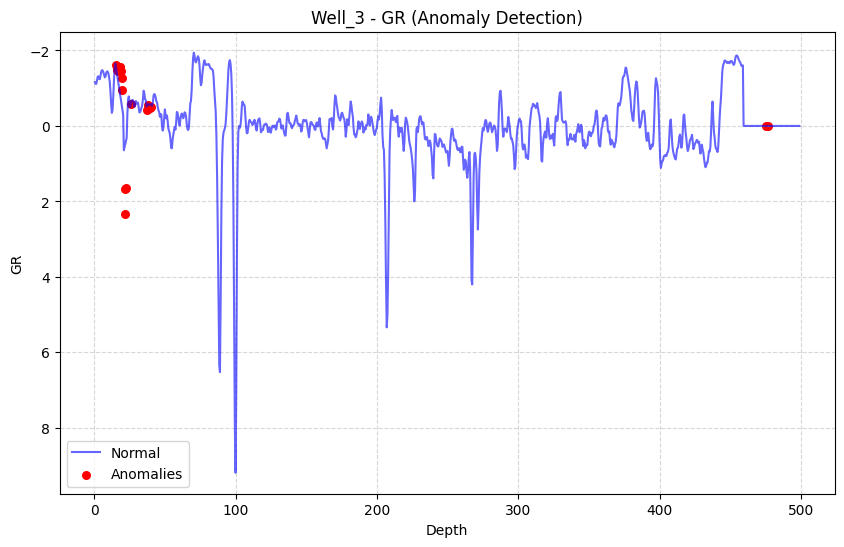

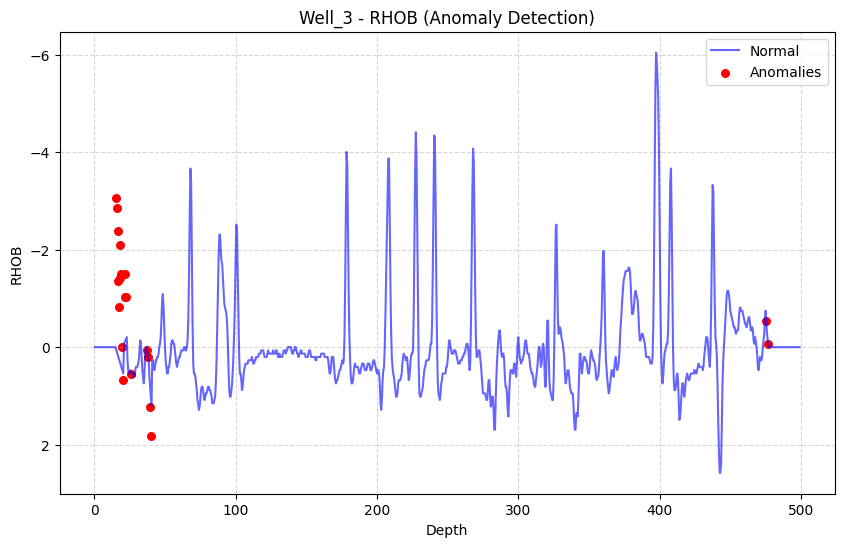

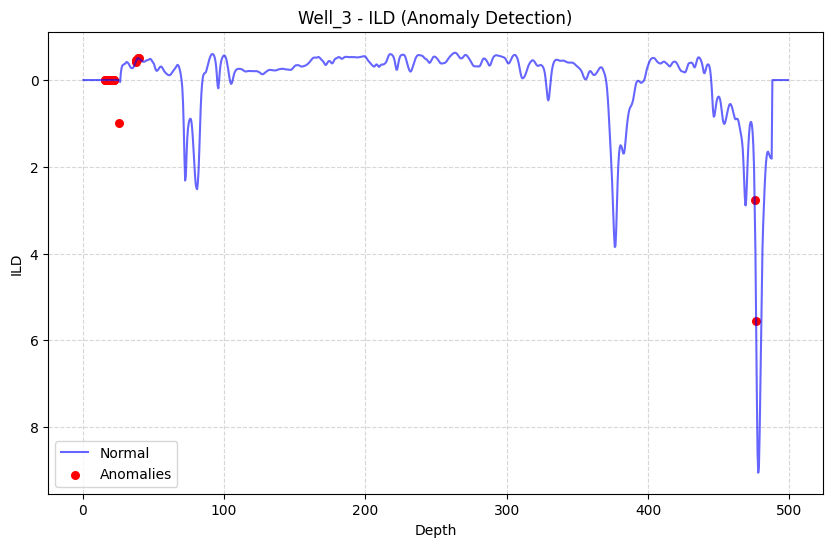

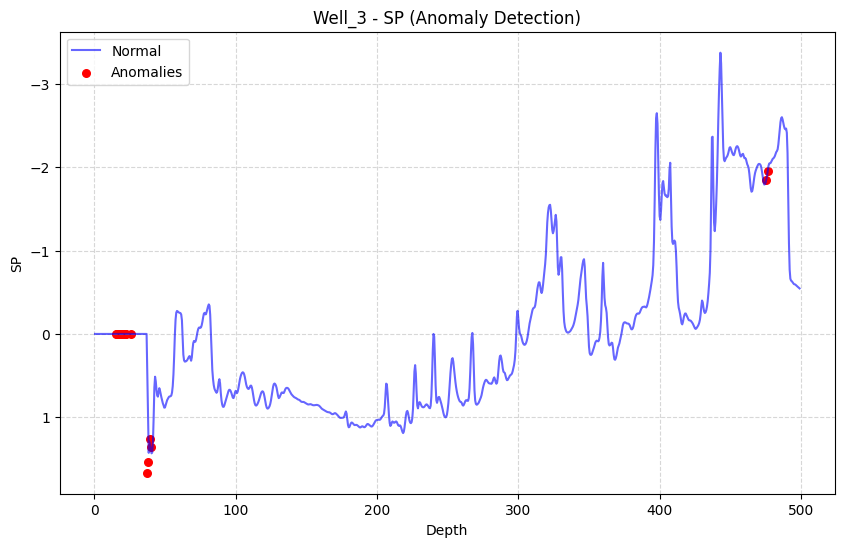

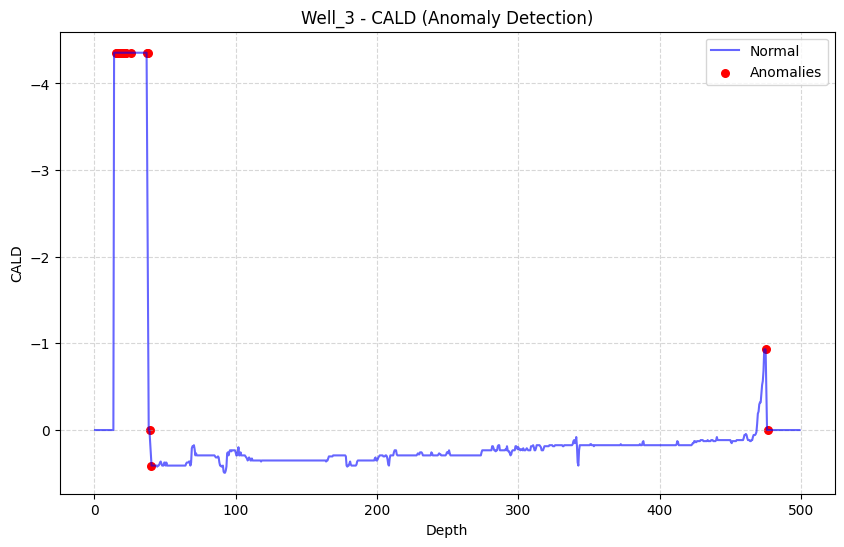

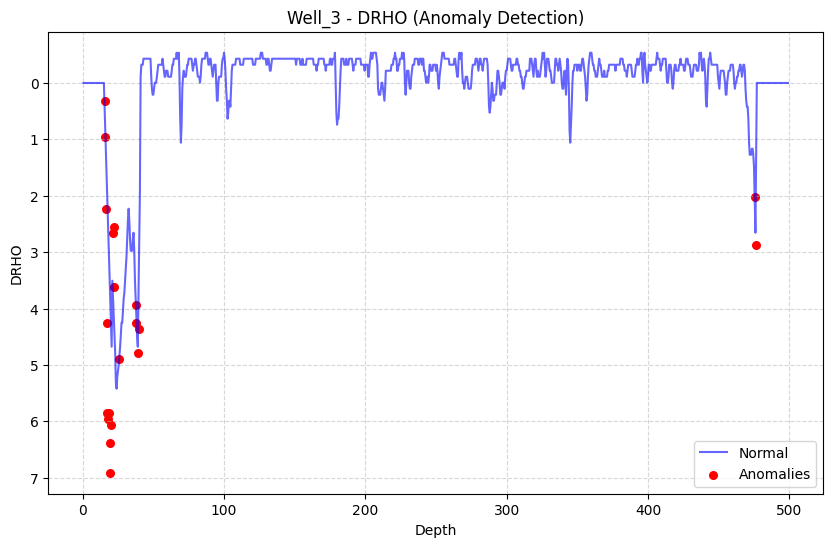


=== Plotting Well_4 ===


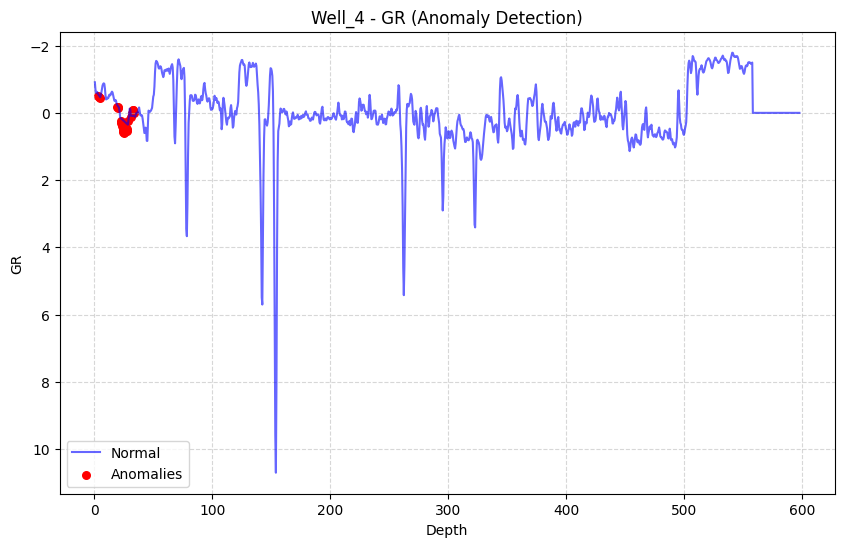

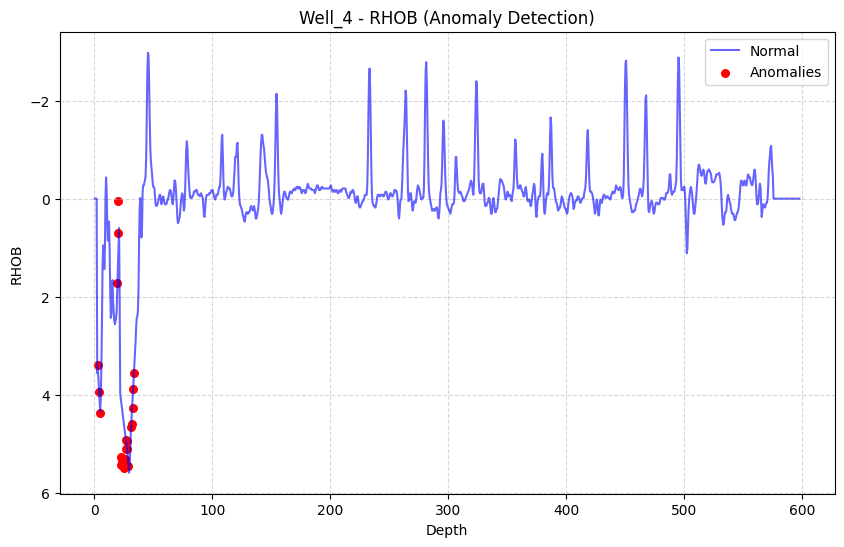

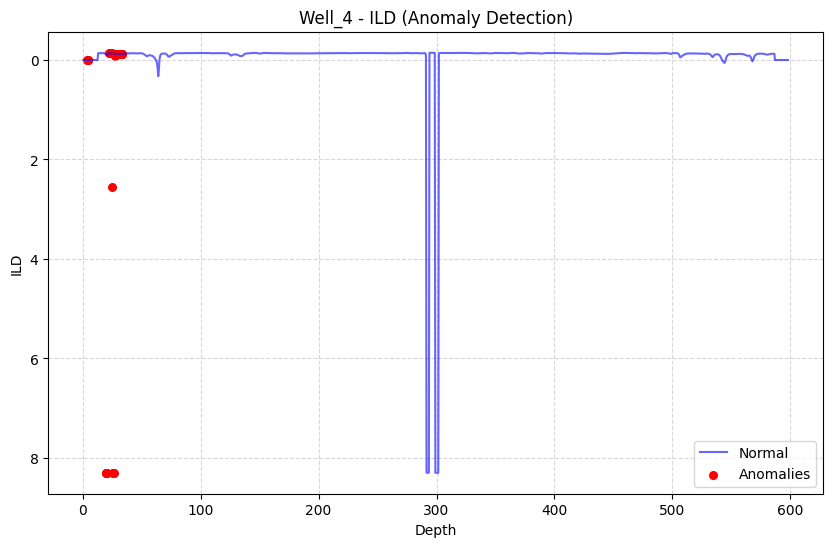

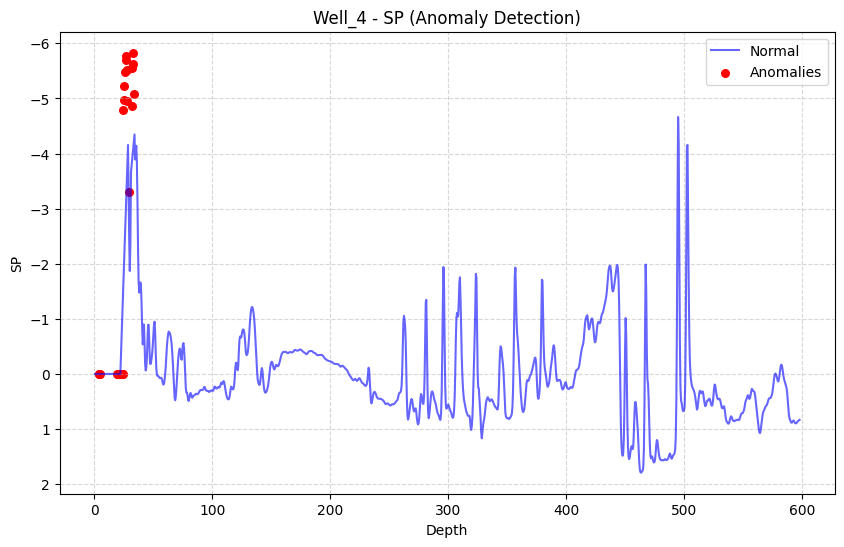

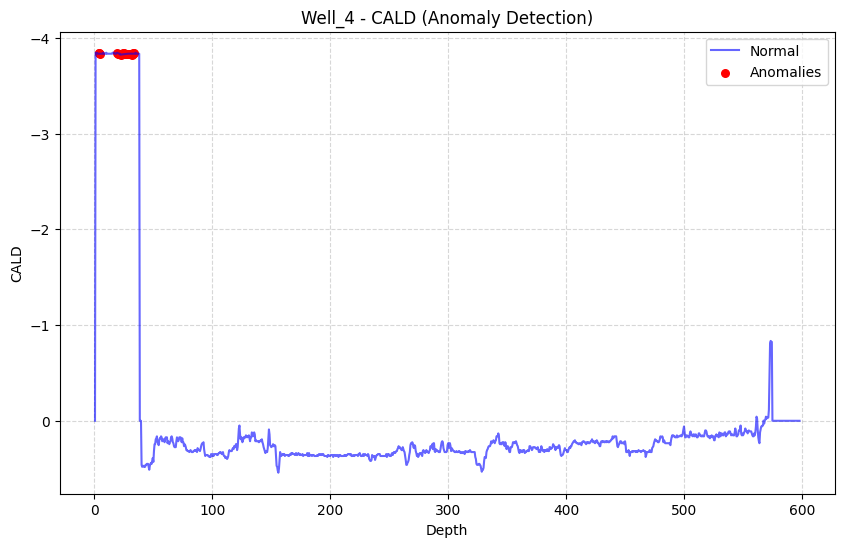

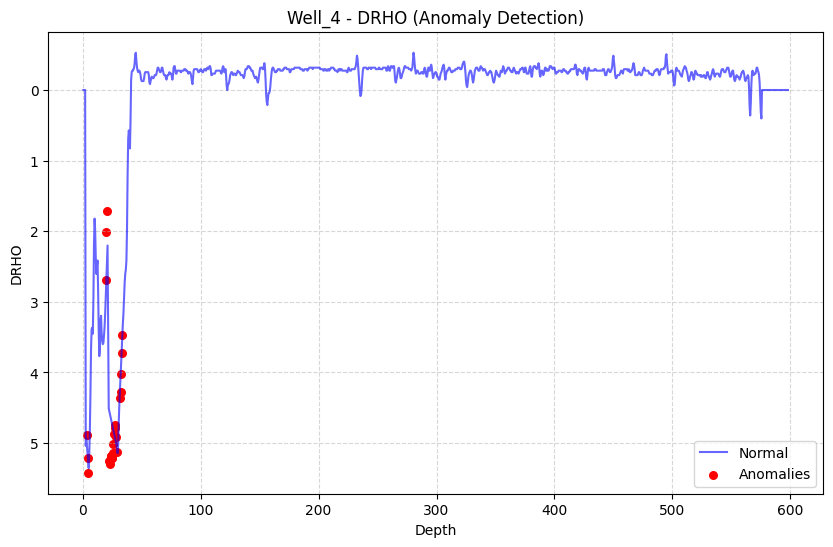

In [141]:

# Visualization function

# For Well 1 
def plot_anomalies(df, well_name, feature='GR'):
    plt.figure(figsize=(10, 6))
    
    # Normal points
    normal = df[df['IF_Anomaly'] == 0]
    anomalies = df[df['IF_Anomaly'] == 1]
    
    plt.plot(normal['DEPT'], normal[feature], label='Normal', color='blue', alpha=0.6)
    plt.scatter(anomalies['DEPT'], anomalies[feature], color='red', label='Anomalies', s=30)
    
   # Depth increases downward
    plt.gca().invert_yaxis()  
    plt.xlabel("Depth")
    plt.ylabel(feature)
    plt.title(f"{well_name} - {feature} (Anomaly Detection)")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

features_to_plot = ['GR', 'RHOB', 'ILD', 'SP', 'CALD', 'DRHO']


# Plot for all well
for well_name, df in wells_anomalies.items():
    print(f"\n=== Plotting {well_name} ===")
    for feature in features_to_plot:
        if feature in df.columns:
            plot_anomalies(df, well_name, feature)


In [142]:

# Create folder for saving plots
output_dir = "plots/Anomalies"
os.makedirs(output_dir, exist_ok=True)

def plot_all_anomalies(df, well_name, features):
    n = len(features)
    fig, axes = plt.subplots(n, 1, figsize=(10, 3*n), sharex=True)
    fig.suptitle(f"{well_name} - Anomaly Detection Across Features", fontsize=16, fontweight='bold')
    
    for i, feature in enumerate(features):
        ax = axes[i] if n > 1 else axes
        if feature not in df.columns:
            continue
        
        normal = df[df['IF_Anomaly'] == 0]
        anomalies = df[df['IF_Anomaly'] == 1]
        
        ax.plot(normal['DEPT'], normal[feature], color='blue', alpha=0.6, label='Normal')
        ax.scatter(anomalies['DEPT'], anomalies[feature], color='red', label='Anomalies', s=25)
        
        # Depth increases downward
        ax.invert_yaxis()  
        ax.set_ylabel(feature, fontsize=10)
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.legend(loc='upper right', fontsize=8)
    
    axes[-1].set_xlabel("Depth", fontsize=10)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    
    # Save plot
    save_path = os.path.join(output_dir, f"{well_name}_Anomalies.png")
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.close()
    
    print(f"Saved: {save_path}")

# === Run for all wells ===
for well_name, df in wells_anomalies.items():
    print(f"\n=== Generating plot for {well_name} ===")
    plot_all_anomalies(df, well_name, ['GR', 'RHOB', 'ILD', 'SP', 'CALD', 'DRHO'])



=== Generating plot for Well_1 ===
Saved: plots/Anomalies\Well_1_Anomalies.png

=== Generating plot for Well_2 ===
Saved: plots/Anomalies\Well_2_Anomalies.png

=== Generating plot for Well_3 ===
Saved: plots/Anomalies\Well_3_Anomalies.png

=== Generating plot for Well_4 ===
Saved: plots/Anomalies\Well_4_Anomalies.png


In [160]:
# Metrics
def compute_anomaly_metrics(df, well_name):
    total = len(df)
    anomalies = df['IF_Anomaly'].sum()
    anomaly_ratio = anomalies / total * 100
    
    # Feature-wise deviation (optional)
    anomaly_stats = df[df['IF_Anomaly'] == 1].drop(columns=['DEPT', 'IF_Anomaly']).mean()
    normal_stats = df[df['IF_Anomaly'] == 0].drop(columns=['DEPT', 'IF_Anomaly']).mean()
    deviation = (anomaly_stats - normal_stats).abs()

    # Print summary
    print(f"\n=== Metrics for {well_name} ===")
    print(f"Total samples: {total}")
    print(f"Anomalies detected: {anomalies} ({anomaly_ratio:.2f}%)")
    print("\nTop features with highest deviation (|Δmean|):")
    print(deviation.sort_values(ascending=False).head(6))
    
    # Return metrics for summary table
    return {
        "Well": well_name,
        "Total": total,
        "Anomalies": anomalies,
        "Anomaly %": round(anomaly_ratio, 2),
        "Top Feature Deviation": deviation.idxmax(),
        "Max |Δmean|": deviation.max()
    }

metrics_summary = []
for well_name, df in wells_anomalies.items():
    metrics_summary.append(compute_anomaly_metrics(df, well_name))

# Display summary as a table
metrics_df = pd.DataFrame(metrics_summary)
print("\n=== Overall Anomaly Metrics Summary ===")
print(metrics_df)



=== Metrics for Well_1 ===
Total samples: 1122
Anomalies detected: 23 (2.05%)

Top features with highest deviation (|Δmean|):
ILD     4.646644
CALD    3.039335
RHOB    1.396549
SP      0.908372
DRHO    0.678798
GR      0.436136
dtype: float64

=== Metrics for Well_2 ===
Total samples: 1081
Anomalies detected: 22 (2.04%)

Top features with highest deviation (|Δmean|):
DRHO    4.943610
CALD    4.599900
ILD     2.299613
RHOB    2.180378
GR      0.661695
SP      0.412181
dtype: float64

=== Metrics for Well_3 ===
Total samples: 998
Anomalies detected: 20 (2.00%)

Top features with highest deviation (|Δmean|):
DRHO    4.115812
CALD    3.581162
RHOB    0.771624
GR      0.574670
ILD     0.378472
SP      0.102304
dtype: float64

=== Metrics for Well_4 ===
Total samples: 1196
Anomalies detected: 24 (2.01%)

Top features with highest deviation (|Δmean|):
DRHO    4.580799
RHOB    4.413695
CALD    3.915123
SP      3.090803
ILD     2.150105
GR      0.167878
dtype: float64

=== Overall Anomaly Metr

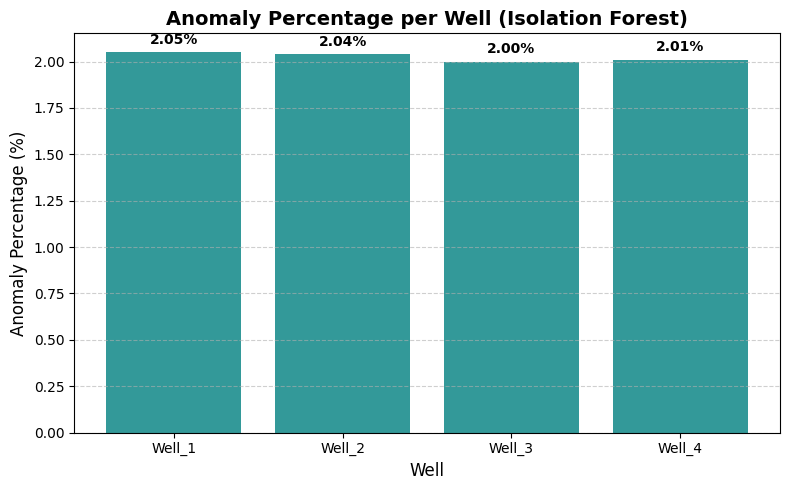

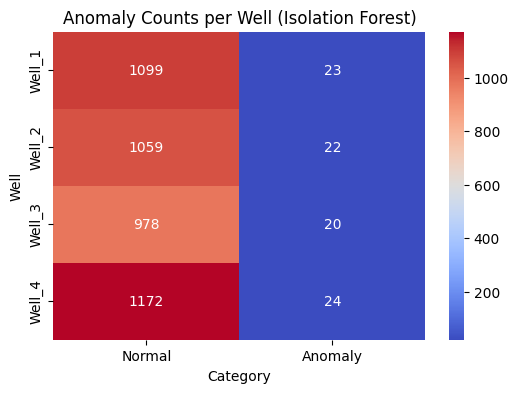

In [144]:

# Isolation Forest anomaly summary
data = {
    'Well': ['Well_1', 'Well_2', 'Well_3', 'Well_4'],
    'Anomaly_%': [2.05, 2.04, 2.00, 2.01]
}

df = pd.DataFrame(data)

# Create folder to save plot
output_folder = "plots/ReportFigures"
os.makedirs(output_folder, exist_ok=True)

# Plot: Anomaly Percentage per Well
plt.figure(figsize=(8, 5))
bars = plt.bar(df['Well'], df['Anomaly_%'], color='teal', alpha=0.8)

# Add values on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.03, f"{height:.2f}%", 
             ha='center', va='bottom', fontsize=10, fontweight='bold')

# Formatting
plt.title('Anomaly Percentage per Well (Isolation Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Well', fontsize=12)
plt.ylabel('Anomaly Percentage (%)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()

# Save and show 
save_path = os.path.join(output_folder, "Anomaly_Percentage_Per_Well.png")
plt.savefig(save_path, dpi=300)
plt.show()

# Anomaly summary
summary = []
for well_name, df in wells_anomalies.items():
    anomalies = df['IF_Anomaly'].sum()
    normals = len(df) - anomalies
    summary.append([well_name, normals, anomalies])

summary_df = pd.DataFrame(summary, columns=['Well', 'Normal', 'Anomaly'])
summary_df.set_index('Well', inplace=True)

# Plot a pseudo confusion-like heatmap
plt.figure(figsize=(6, 4))
sns.heatmap(summary_df, annot=True, fmt='d', cmap='coolwarm')
plt.title("Anomaly Counts per Well (Isolation Forest)")
plt.ylabel("Well")
plt.xlabel("Category")
plt.show()


### Autoencoder Algorithms

In [145]:
def build_autoencoder(input_dim):
    input_layer = Input(shape=(input_dim,))
    
    # Encoder
    encoded = Dense(64, activation='relu')(input_layer)
    encoded = Dense(32, activation='relu')(encoded)
    encoded = Dense(16, activation='relu')(encoded)
    
    # Decoder
    decoded = Dense(32, activation='relu')(encoded)
    decoded = Dense(64, activation='relu')(decoded)
    output_layer = Dense(input_dim, activation='linear')(decoded)
    
    # Compile model
    autoencoder = Model(inputs=input_layer, outputs=output_layer)
    autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
    return autoencoder


def detect_anomalies_autoencoder(df_scaled, well_name, threshold_percentile=95, epochs=50, batch_size=32):
    print(f"\n=== Training Autoencoder for {well_name} ===")
    
    # Prepare features
    X = df_scaled.drop(columns=['DEPT']).values
    input_dim = X.shape[1]
    
    # Build and train
    autoencoder = build_autoencoder(input_dim)
    history = autoencoder.fit(
        X, X,
        epochs=epochs,
        batch_size=batch_size,
        shuffle=True,
        verbose=0
    )
    
    # Reconstruction
    reconstructed = autoencoder.predict(X)
    mse = np.mean(np.power(X - reconstructed, 2), axis=1)
    df_scaled['AE_Recon_Error'] = mse
    
    # Threshold for anomaly
    threshold = np.percentile(mse, threshold_percentile)
    df_scaled['AE_Anomaly'] = (mse > threshold).astype(int)
    
    print(f"Anomalies detected: {df_scaled['AE_Anomaly'].sum()} ({threshold_percentile}th percentile threshold)")
    
    # Return model and data
    return df_scaled, autoencoder, threshold

wells_autoencoder = {}
for name, df in wells_anomalies.items():
    df_auto, model, thresh = detect_anomalies_autoencoder(df.copy(), name)
    wells_autoencoder[name] = df_auto




=== Training Autoencoder for Well_1 ===
36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step
Anomalies detected: 57 (95th percentile threshold)

=== Training Autoencoder for Well_2 ===
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Anomalies detected: 54 (95th percentile threshold)

=== Training Autoencoder for Well_3 ===
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Anomalies detected: 50 (95th percentile threshold)

=== Training Autoencoder for Well_4 ===
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
Anomalies detected: 60 (95th percentile threshold)


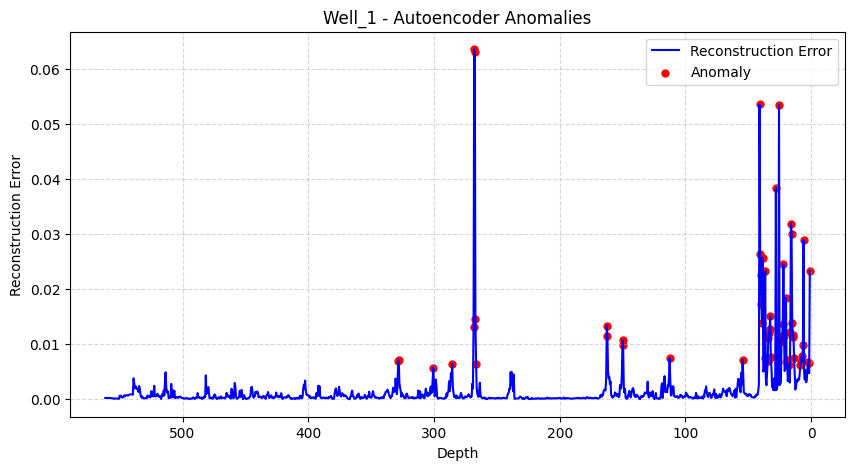

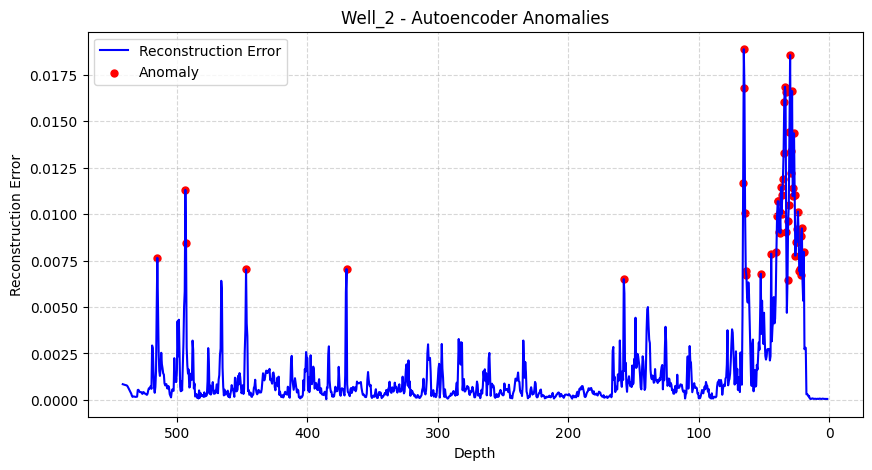

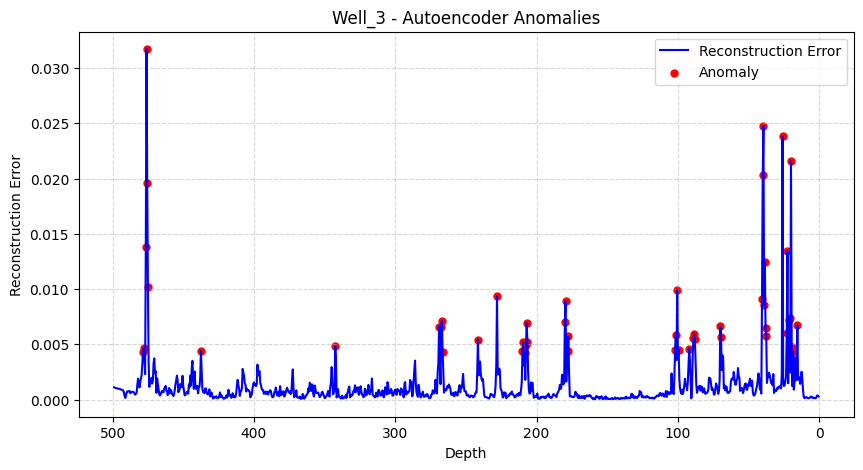

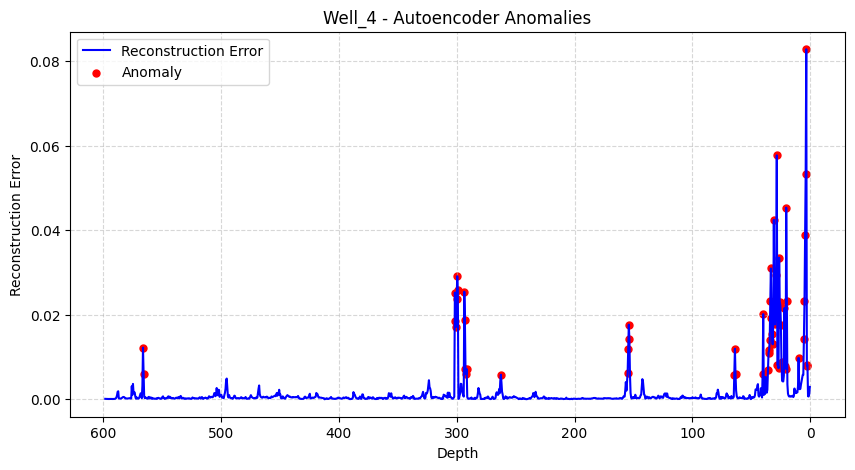

In [146]:
def plot_reconstruction_error(df, well_name):
    plt.figure(figsize=(10, 5))
    plt.plot(df['DEPT'], df['AE_Recon_Error'], label='Reconstruction Error', color='blue')
    plt.scatter(df[df['AE_Anomaly'] == 1]['DEPT'],
                df[df['AE_Anomaly'] == 1]['AE_Recon_Error'],
                color='red', label='Anomaly', s=25)
    plt.gca().invert_xaxis()
    plt.xlabel("Depth")
    plt.ylabel("Reconstruction Error")
    plt.title(f"{well_name} - Autoencoder Anomalies")
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

for name, df in wells_autoencoder.items():
    plot_reconstruction_error(df, name)


In [147]:
for name in wells_autoencoder.keys():
    df_if = wells_anomalies[name]
    df_ae = wells_autoencoder[name]
    overlap = np.sum((df_if['IF_Anomaly'] == 1) & (df_ae['AE_Anomaly'] == 1))
    print(f"{name}: Overlap of anomalies (IF & AE) = {overlap}")


Well_1: Overlap of anomalies (IF & AE) = 17
Well_2: Overlap of anomalies (IF & AE) = 18
Well_3: Overlap of anomalies (IF & AE) = 13
Well_4: Overlap of anomalies (IF & AE) = 19


In [148]:
def compare_anomaly_metrics(df, well_name):
    total_points = len(df)
    
    # Isolation Forest metrics
    if_anomalies = df['IF_Anomaly'].sum()
    if_percent = (if_anomalies / total_points) * 100
    
    # Autoencoder metrics
    ae_anomalies = df['AE_Anomaly'].sum()
    ae_percent = (ae_anomalies / total_points) * 100
    
    # Overlap between both methods
    overlap = np.sum((df['IF_Anomaly'] == 1) & (df['AE_Anomaly'] == 1))
    overlap_percent = (overlap / total_points) * 100
    
    # Reconstruction error stats
    mean_recon = df['AE_Recon_Error'].mean()
    std_recon = df['AE_Recon_Error'].std()
    
    return {
        "Well": well_name,
        "Total Points": total_points,
        "IF_Anomalies": if_anomalies,
        "IF_%": round(if_percent, 2),
        "AE_Anomalies": ae_anomalies,
        "AE_%": round(ae_percent, 2),
        "Overlap": overlap,
        "Overlap_%": round(overlap_percent, 2),
        "AE_Recon_Mean": round(mean_recon, 6),
        "AE_Recon_Std": round(std_recon, 6)
    }


In [149]:
combined_metrics_summary = []
for well_name, df in wells_autoencoder.items():
    combined_metrics_summary.append(compare_anomaly_metrics(df, well_name))

# Create and view summary
metrics_df = pd.DataFrame(combined_metrics_summary)
print("\n=== Isolation Forest vs Autoencoder Summary ===")
print(metrics_df)



=== Isolation Forest vs Autoencoder Summary ===
     Well  Total Points  IF_Anomalies  IF_%  AE_Anomalies  AE_%  Overlap  \
0  Well_1          1122            23  2.05            57  5.08       17   
1  Well_2          1081            22  2.04            54  5.00       18   
2  Well_3           998            20  2.00            50  5.01       13   
3  Well_4          1196            24  2.01            60  5.02       19   

   Overlap_%  AE_Recon_Mean  AE_Recon_Std  
0       1.52       0.001626      0.004725  
1       1.67       0.001408      0.002442  
2       1.30       0.001222      0.002306  
3       1.59       0.001502      0.005240  


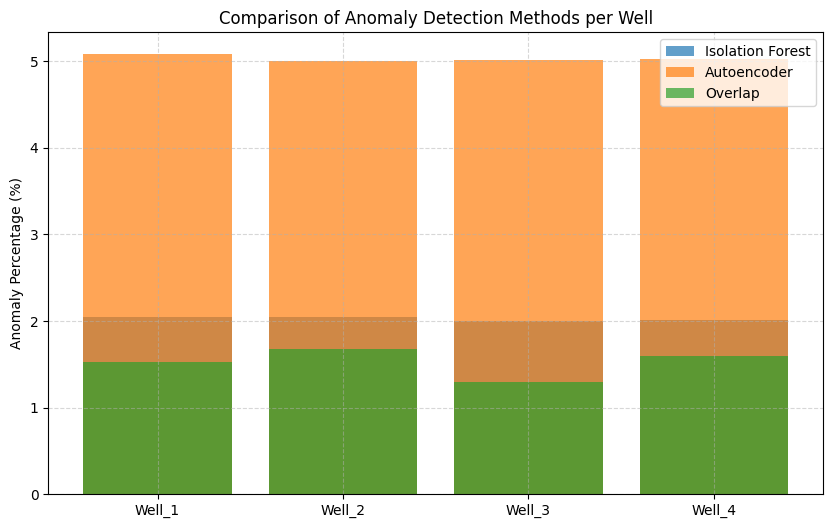

In [150]:
plt.figure(figsize=(10, 6))
plt.bar(metrics_df["Well"], metrics_df["IF_%"], alpha=0.7, label="Isolation Forest")
plt.bar(metrics_df["Well"], metrics_df["AE_%"], alpha=0.7, label="Autoencoder")
plt.bar(metrics_df["Well"], metrics_df["Overlap_%"], alpha=0.7, label="Overlap")
plt.ylabel("Anomaly Percentage (%)")
plt.title("Comparison of Anomaly Detection Methods per Well")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()


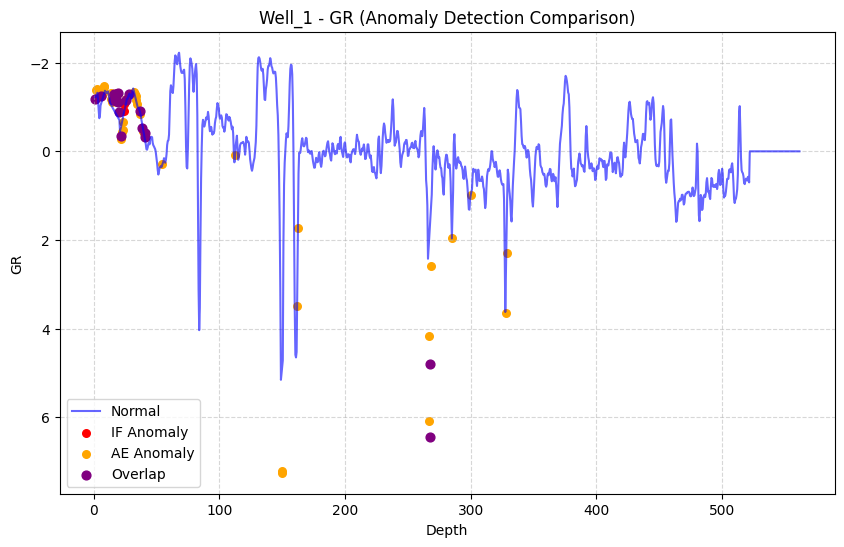

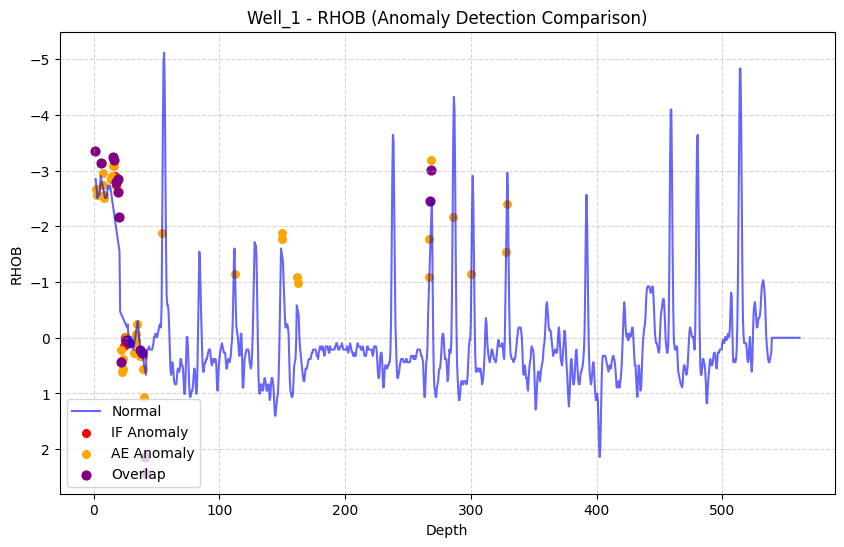

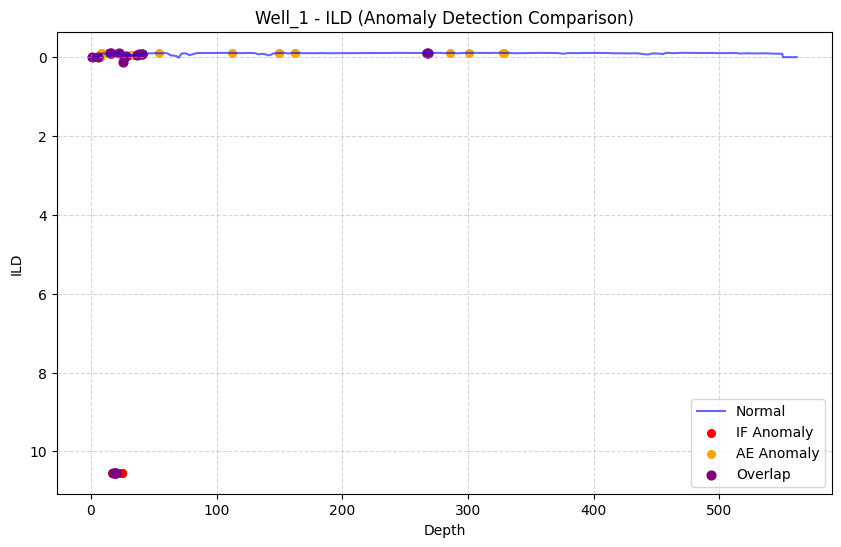

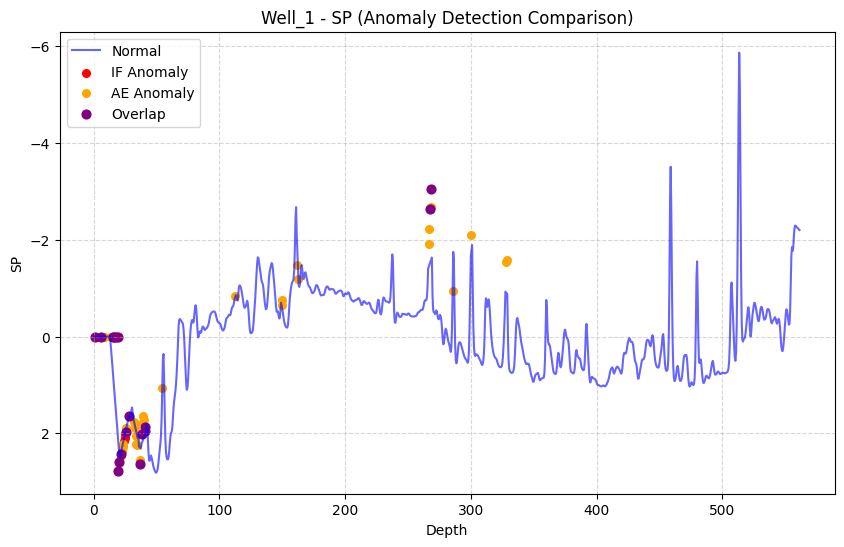

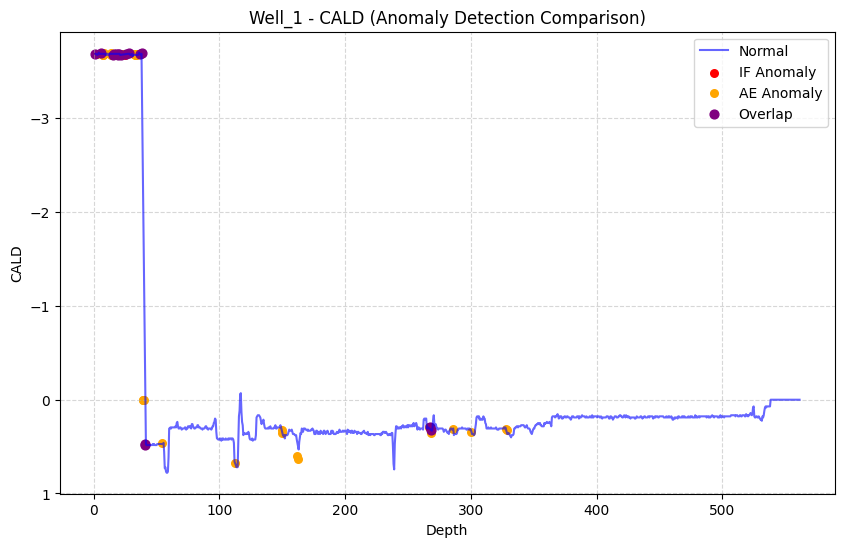

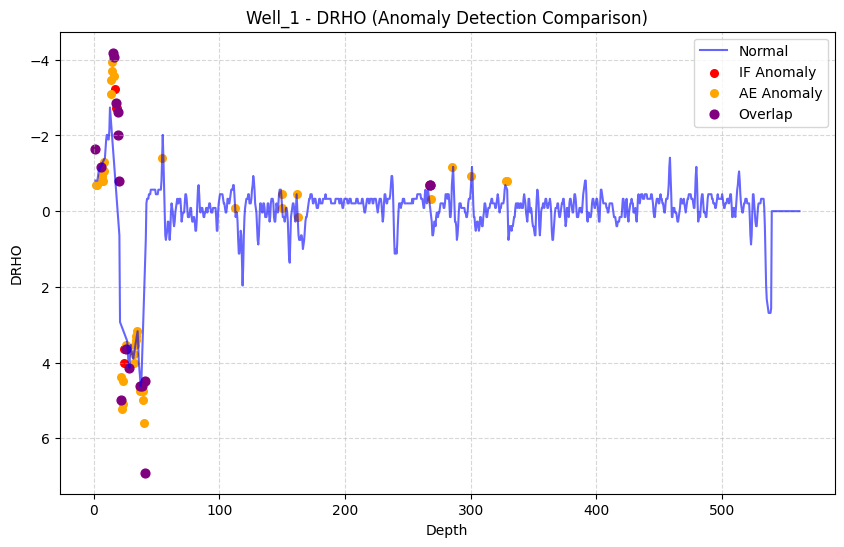

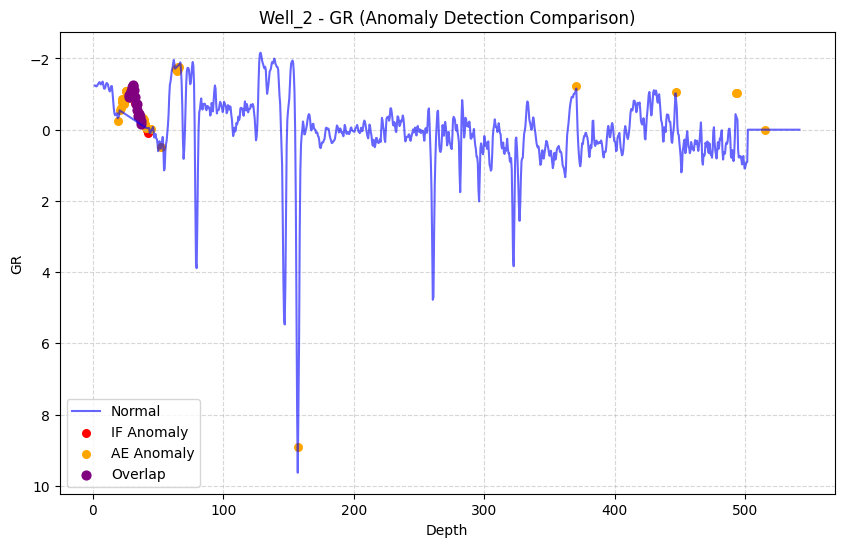

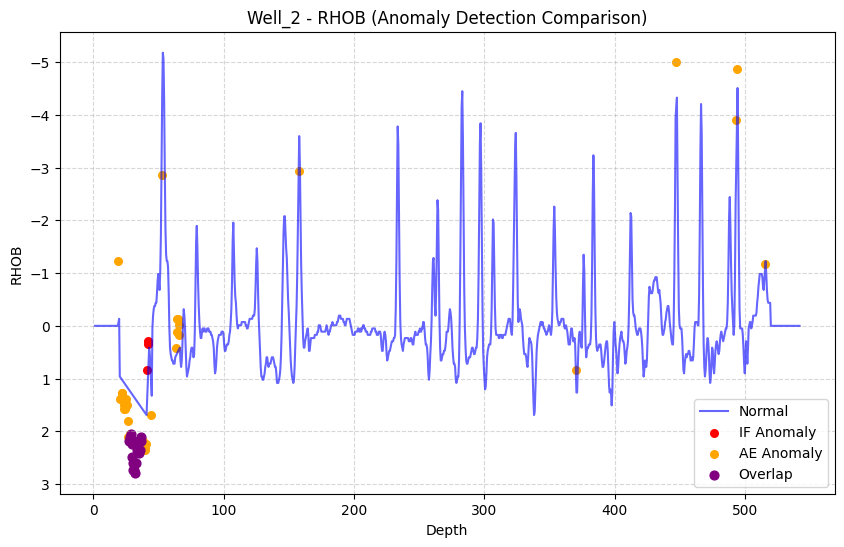

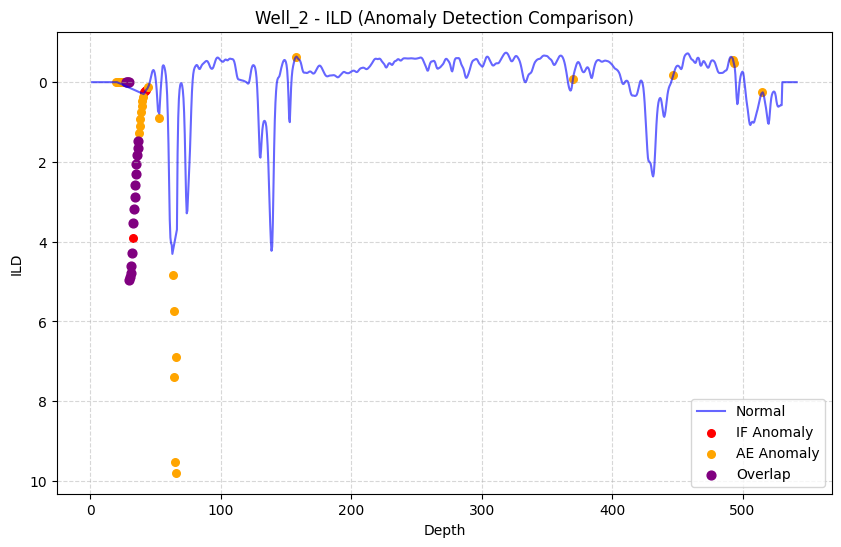

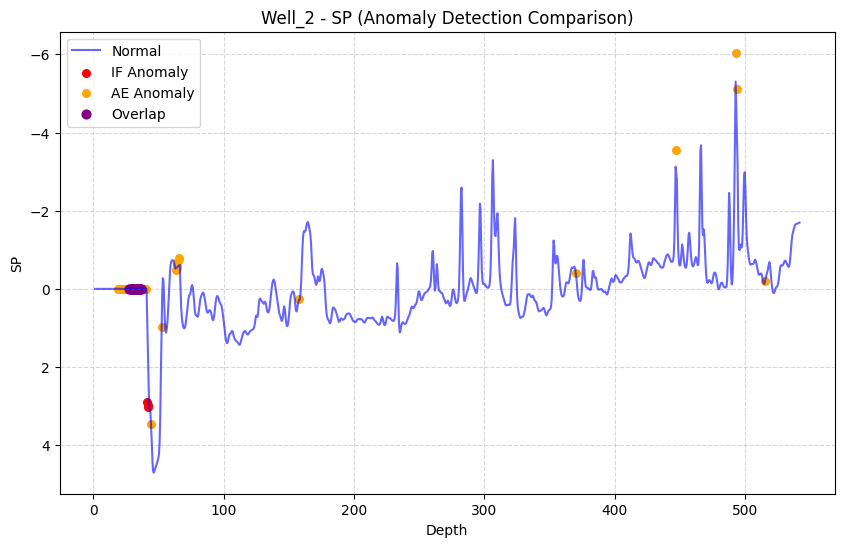

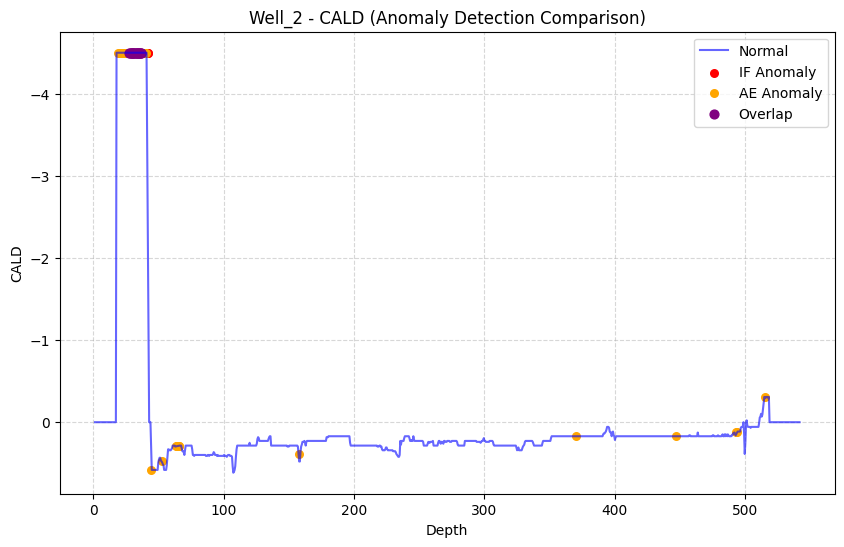

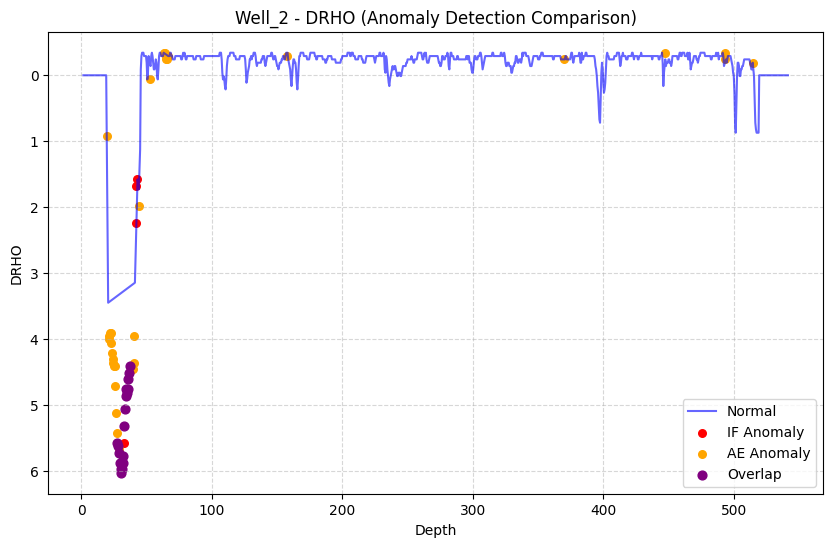

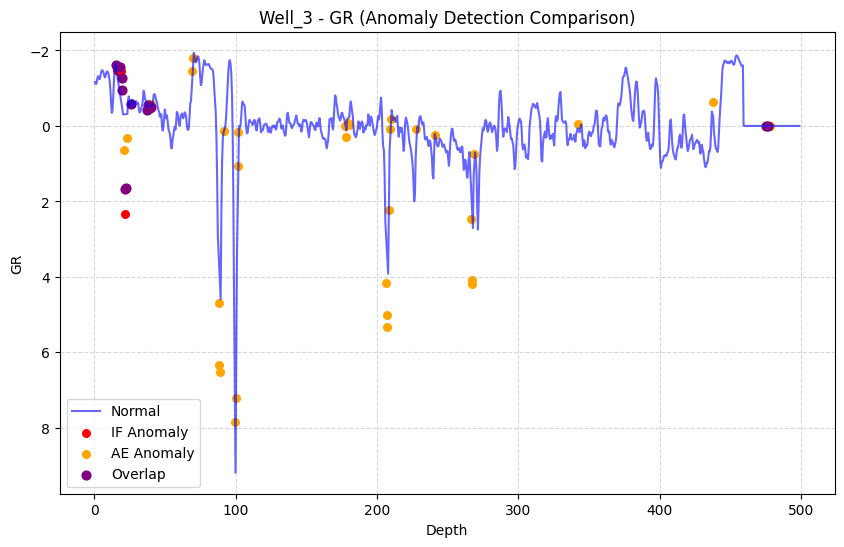

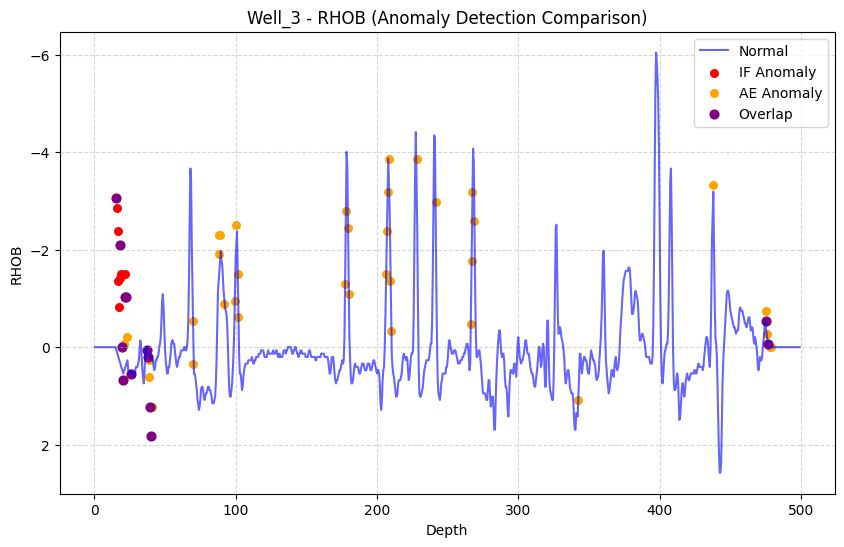

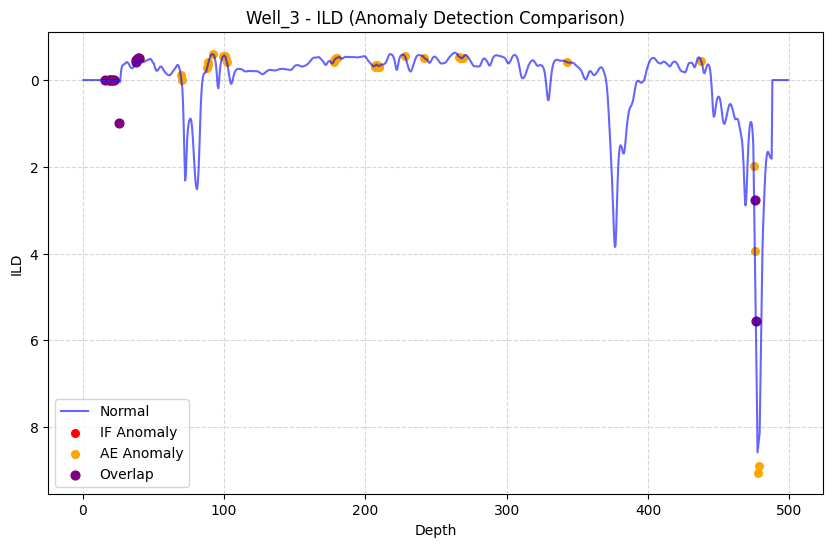

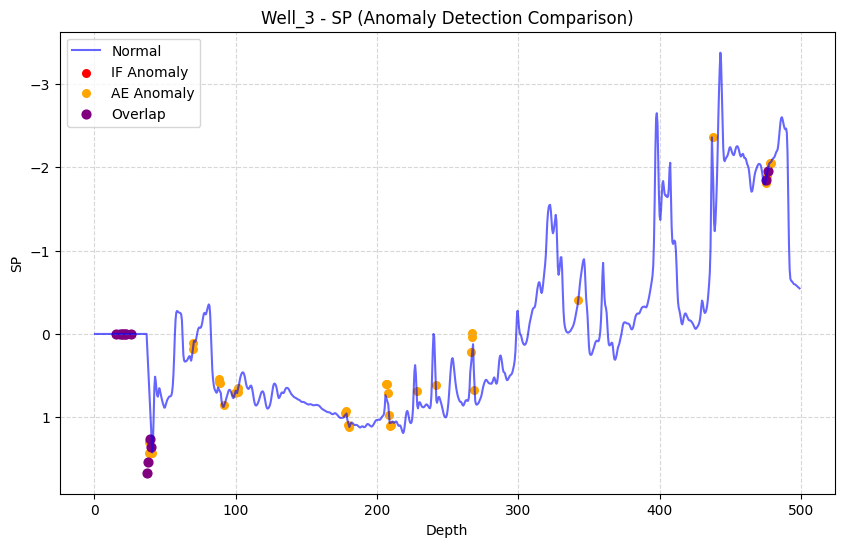

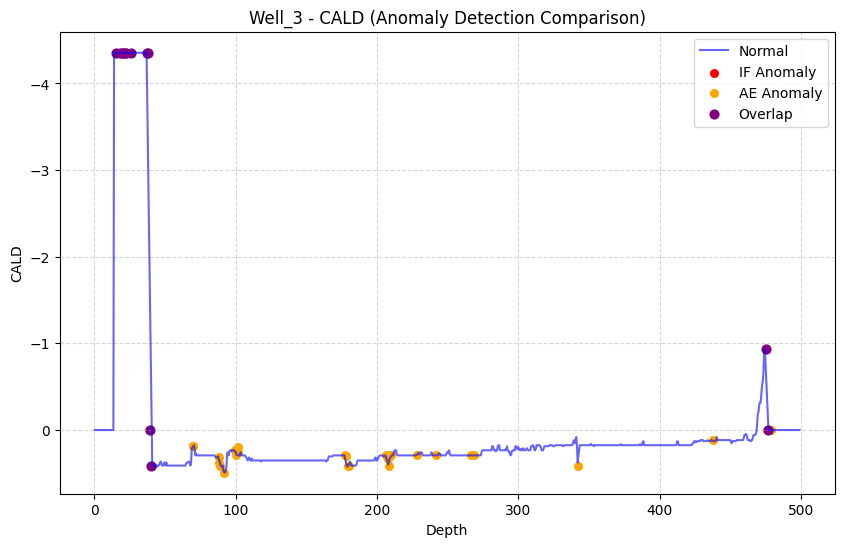

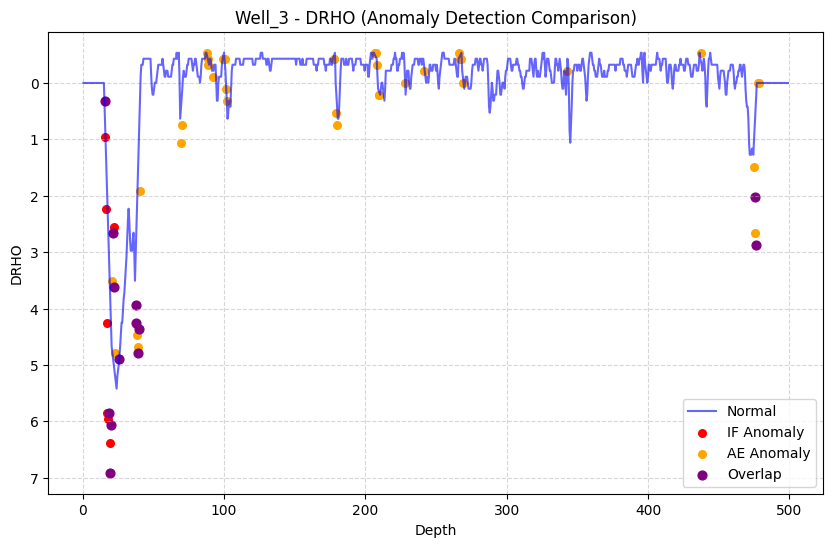

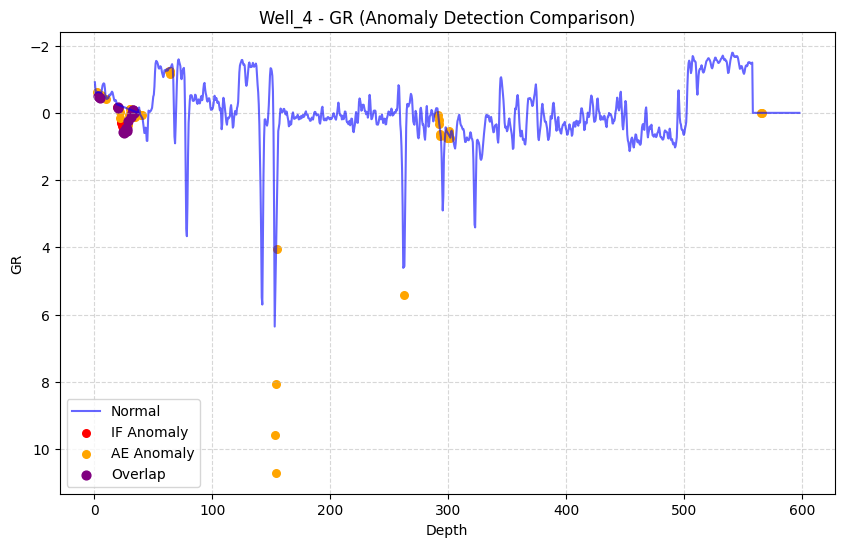

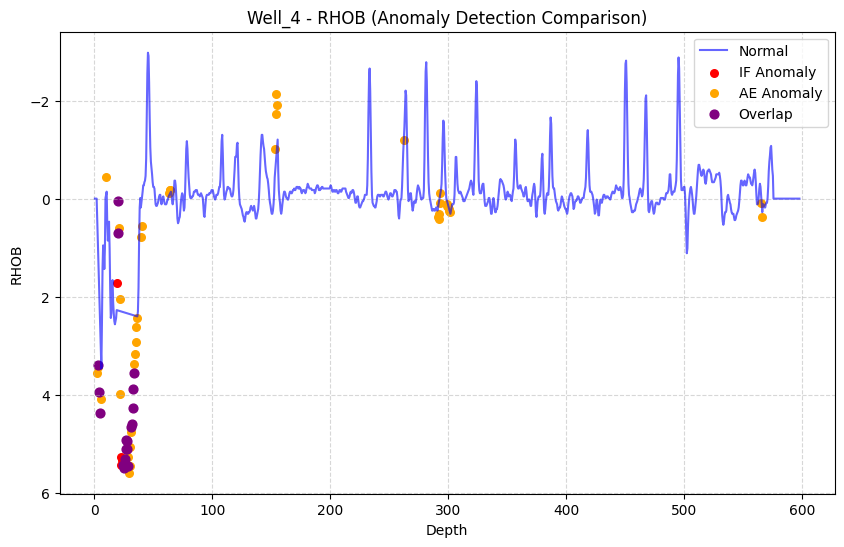

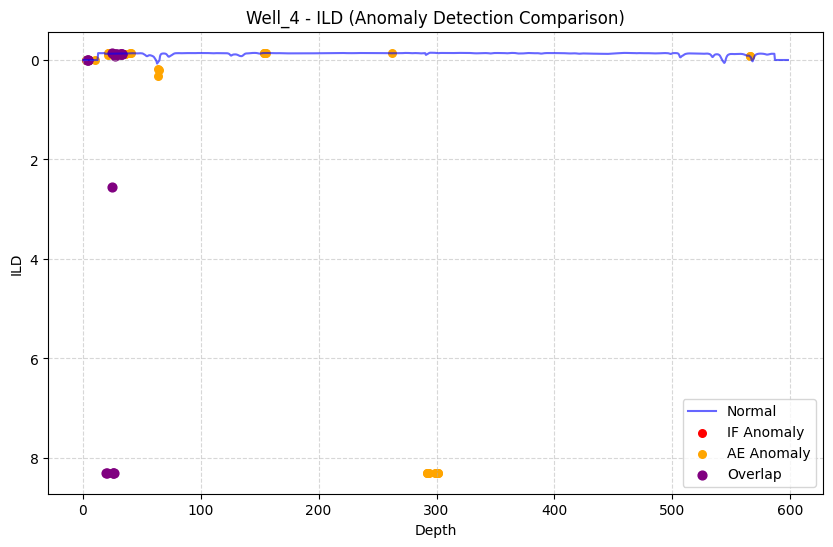

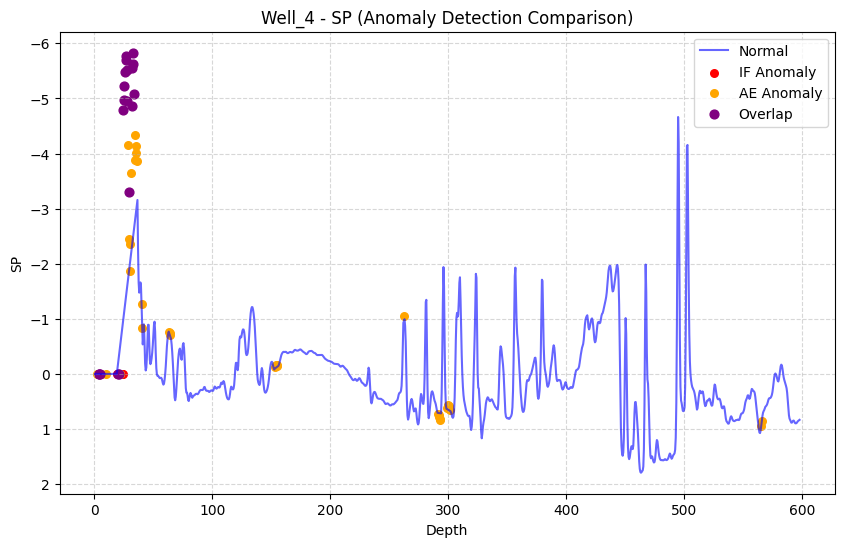

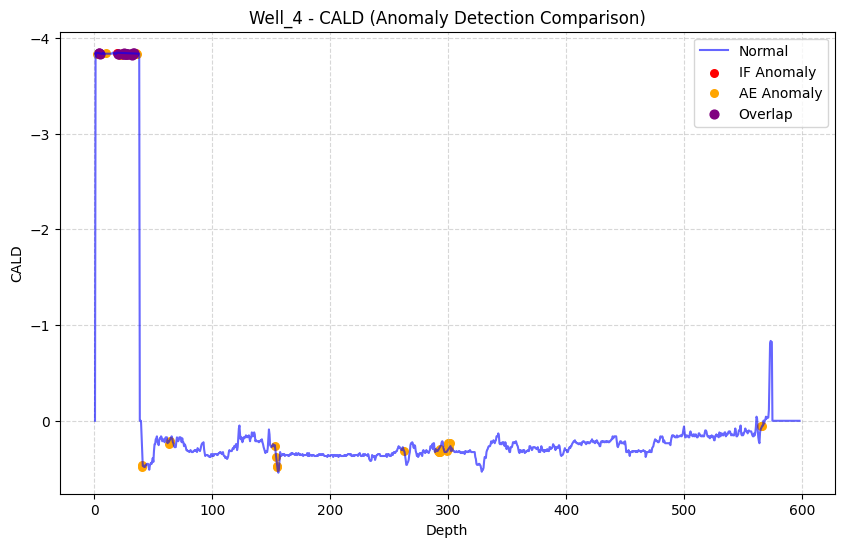

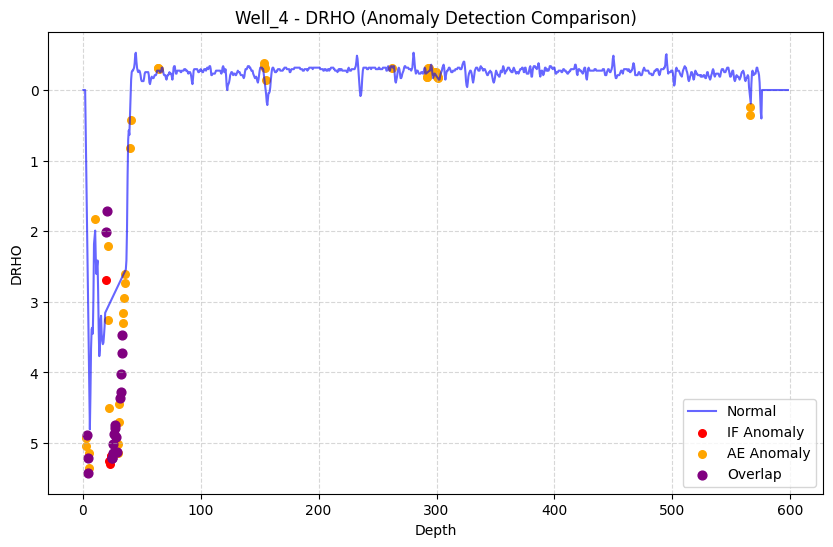

In [151]:


def plot_combined_anomalies(df, well_name, feature='GR'):
    plt.figure(figsize=(10, 6))
    
    # Normal points
    normal = df[(df['IF_Anomaly'] == 0) & (df['AE_Anomaly'] == 0)]
    if_anomaly = df[(df['IF_Anomaly'] == 1) & (df['AE_Anomaly'] == 0)]
    ae_anomaly = df[(df['IF_Anomaly'] == 0) & (df['AE_Anomaly'] == 1)]
    overlap = df[(df['IF_Anomaly'] == 1) & (df['AE_Anomaly'] == 1)]
    
    # Plot normal
    plt.plot(normal['DEPT'], normal[feature], color='blue', alpha=0.6, label='Normal')
    
    # Plot anomalies
    plt.scatter(if_anomaly['DEPT'], if_anomaly[feature], color='red', label='IF Anomaly', s=30)
    plt.scatter(ae_anomaly['DEPT'], ae_anomaly[feature], color='orange', label='AE Anomaly', s=30)
    plt.scatter(overlap['DEPT'], overlap[feature], color='purple', label='Overlap', s=40)
    
    plt.gca().invert_yaxis()  # Depth increases downward
    plt.xlabel('Depth')
    plt.ylabel(feature)
    plt.title(f'{well_name} - {feature} (Anomaly Detection Comparison)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()

# Plot for all wells and key features
features = ['GR', 'RHOB', 'ILD', 'SP', 'CALD', 'DRHO']

for well_name, df in wells_autoencoder.items():
    for feature in features:
        plot_combined_anomalies(df, well_name, feature)


In [152]:
with PdfPages('Well_Anomaly_Report.pdf') as pdf:
    # Add a title page
    plt.figure(figsize=(8,6))
    plt.text(0.5, 0.5, 'Well Log Anomaly Detection Report\nPrototype', 
             horizontalalignment='center', verticalalignment='center', fontsize=20)
    plt.axis('off')
    pdf.savefig()
    plt.close()
    
    # Add metrics table
    fig, ax = plt.subplots(figsize=(10, 2))
    ax.axis('tight')
    ax.axis('off')
    table = ax.table(cellText=metrics_df.values,
                     colLabels=metrics_df.columns,
                     loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1, 2)
    pdf.savefig()
    plt.close()
    
    # Add anomaly plots per well & feature
    def plot_combined_anomalies(df, well_name, feature):
        fig, ax = plt.subplots(figsize=(8, 4))
        ax.plot(df['Depth'], df[feature], label=feature)
        if 'Anomaly' in df.columns:
            ax.scatter(df['Depth'][df['Anomaly']], df[feature][df['Anomaly']], color='red', label='Anomaly')
        ax.set_title(f"{well_name} - {feature}")
        ax.set_xlabel("Depth")
        ax.set_ylabel(feature)
        ax.legend()
        return fig


In [153]:
# Combining the Anomalies
def plot_combined_anomalies(df, well_name, feature='GR'):
    plt.figure(figsize=(10, 6))
    
    normal = df[(df['IF_Anomaly'] == 0) & (df['AE_Anomaly'] == 0)]
    if_anomaly = df[(df['IF_Anomaly'] == 1) & (df['AE_Anomaly'] == 0)]
    ae_anomaly = df[(df['IF_Anomaly'] == 0) & (df['AE_Anomaly'] == 1)]
    overlap = df[(df['IF_Anomaly'] == 1) & (df['AE_Anomaly'] == 1)]
    
    plt.plot(normal['DEPT'], normal[feature], color='blue', alpha=0.6, label='Normal')
    plt.scatter(if_anomaly['DEPT'], if_anomaly[feature], color='red', label='IF Anomaly', s=30)
    plt.scatter(ae_anomaly['DEPT'], ae_anomaly[feature], color='orange', label='AE Anomaly', s=30)
    plt.scatter(overlap['DEPT'], overlap[feature], color='purple', label='Overlap', s=40)
    
    plt.gca().invert_yaxis()
    plt.xlabel('Depth')
    plt.ylabel(feature)
    plt.title(f'{well_name} - {feature} (Anomaly Detection)')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    return plt


In [154]:
# Comparing Metrics
def compare_anomaly_metrics(df, well_name):
    total_points = len(df)
    if_anomalies = df['IF_Anomaly'].sum()
    ae_anomalies = df['AE_Anomaly'].sum()
    overlap = np.sum((df['IF_Anomaly']==1) & (df['AE_Anomaly']==1))
    
    return {
        "Well": well_name,
        "Total Points": total_points,
        "IF_Anomalies": if_anomalies,
        "IF_%": round((if_anomalies/total_points)*100,2),
        "AE_Anomalies": ae_anomalies,
        "AE_%": round((ae_anomalies/total_points)*100,2),
        "Overlap": overlap,
        "Overlap_%": round((overlap/total_points)*100,2),
        "AE_Recon_Mean": round(df['AE_Recon_Error'].mean(),6),
        "AE_Recon_Std": round(df['AE_Recon_Error'].std(),6)
    }


In [155]:
# Print Metrics 
metrics_summary = []
for well_name, df in wells_autoencoder.items():
    metrics_summary.append(compare_anomaly_metrics(df, well_name))

metrics_df = pd.DataFrame(metrics_summary)
print(metrics_df)




     Well  Total Points  IF_Anomalies  IF_%  AE_Anomalies  AE_%  Overlap  \
0  Well_1          1122            23  2.05            57  5.08       17   
1  Well_2          1081            22  2.04            54  5.00       18   
2  Well_3           998            20  2.00            50  5.01       13   
3  Well_4          1196            24  2.01            60  5.02       19   

   Overlap_%  AE_Recon_Mean  AE_Recon_Std  
0       1.52       0.001626      0.004725  
1       1.67       0.001408      0.002442  
2       1.30       0.001222      0.002306  
3       1.59       0.001502      0.005240  


In [156]:


# Creating a Folders
pdf_path = r"C:\Users\LENOVO\Downloads\SASTRA_PROJECT\Well_Anomaly_Report1.pdf"
plot_folder = r"C:\Users\LENOVO\Downloads\SASTRA_PROJECT\Well_Plots"
csv_folder = r"C:\Users\LENOVO\Downloads\SASTRA_PROJECT\Well_CSV"

os.makedirs(plot_folder, exist_ok=True)
os.makedirs(csv_folder, exist_ok=True)

# Logo
logo_path = r"C:\Users\LENOVO\Downloads\SASTRA_PROJECT\sastratransp.png"

# Creating PDF
with PdfPages(pdf_path) as pdf:
    
    # Title Page
    plt.figure(figsize=(8,6))
    plt.axis('off')
    
    if os.path.exists(logo_path):
        logo = mpimg.imread(logo_path)
        plt.imshow(logo, extent=[0.3, 0.7, 0.7, 0.95], aspect='auto')
    else:
        print("Logo file not found. Skipping logo.")
    
    plt.text(0.5, 0.6, 
             'A Prototype Application for\nMachine Learning-Based\nAnomaly Detection in Well Log Data',
             horizontalalignment='center', verticalalignment='center', fontsize=18, fontweight='bold')
    
    plt.text(0.5, 0.45, 'Author: Umar Zakariyya Muhammad', horizontalalignment='center', fontsize=12)
    plt.text(0.5, 0.40, 'Email: zakariyyaumarm@gmail.com', horizontalalignment='center', fontsize=12)
    plt.text(0.5, 0.35, 'Phone: +234 8100715174', horizontalalignment='center', fontsize=12)
    
    pdf.savefig()
    plt.close()
    
    # Metrics Table 
    fig, ax = plt.subplots(figsize=(10, 5))
    ax.axis('tight')
    ax.axis('off')
    table = ax.table(cellText=metrics_df.values,
                     colLabels=metrics_df.columns,
                     loc='center')
    table.auto_set_font_size(False)
    table.set_fontsize(10)
    table.scale(1.2, 2)
    pdf.savefig()
    plt.close()
    
    # Anomaly Plots & CSV per well
    features = ['GR', 'RHOB', 'ILD', 'SP', 'CALD', 'DRHO']
    
    for well_name, df in wells_autoencoder.items():
        
        # Save CSV for this well
        csv_file = os.path.join(csv_folder, f"{well_name}_Anomalies.csv")
        df.to_csv(csv_file, index=False)
        
        for feature in features:
            plt.figure(figsize=(10, 6))
            
            normal = df[(df['IF_Anomaly']==0) & (df['AE_Anomaly']==0)]
            if_anomaly = df[(df['IF_Anomaly']==1) & (df['AE_Anomaly']==0)]
            ae_anomaly = df[(df['IF_Anomaly']==0) & (df['AE_Anomaly']==1)]
            overlap = df[(df['IF_Anomaly']==1) & (df['AE_Anomaly']==1)]
            
            plt.plot(normal['DEPT'], normal[feature], color='blue', alpha=0.6, label='Normal')
            plt.scatter(if_anomaly['DEPT'], if_anomaly[feature], color='red', label='IF Anomaly', s=30)
            plt.scatter(ae_anomaly['DEPT'], ae_anomaly[feature], color='orange', label='AE Anomaly', s=30)
            plt.scatter(overlap['DEPT'], overlap[feature], color='purple', label='Overlap', s=40)
            
            plt.gca().invert_yaxis()
            plt.xlabel('Depth')
            plt.ylabel(feature)
            plt.title(f'{well_name} - {feature} (Anomaly Detection)')
            plt.legend()
            plt.grid(True, linestyle='--', alpha=0.5)
            plt.tight_layout()
            
            # Save plot to folder
            plot_file = os.path.join(plot_folder, f"{well_name}_{feature}_Anomalies.png")
            plt.savefig(plot_file, dpi=300, bbox_inches='tight')
            
            # Add to PDF
            pdf.savefig()
            plt.close()


Logo file not found. Skipping logo.


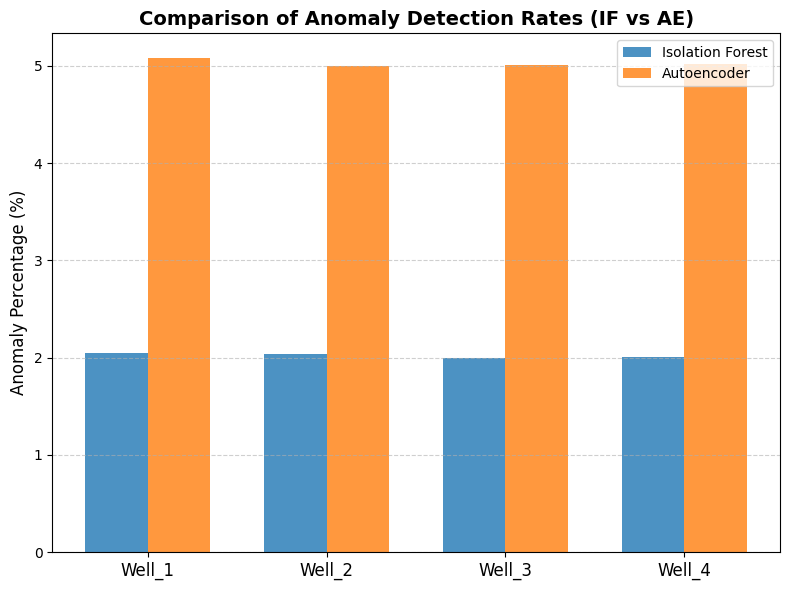

In [157]:


# Data (from my results)
data = {
    'Well': ['Well_1', 'Well_2', 'Well_3', 'Well_4'],
    'IF_%': [2.05, 2.04, 2.00, 2.01],
    'AE_%': [5.08, 5.00, 5.01, 5.02]
}

df = pd.DataFrame(data)

# Create output folder
output_folder = "plots/ReportFigures"
os.makedirs(output_folder, exist_ok=True)

# Plot grouped bar chart
plt.figure(figsize=(8, 6))
bar_width = 0.35
x = range(len(df))

plt.bar([i - bar_width/2 for i in x], df['IF_%'], width=bar_width, label='Isolation Forest', alpha=0.8)
plt.bar([i + bar_width/2 for i in x], df['AE_%'], width=bar_width, label='Autoencoder', alpha=0.8)

# Formatting
plt.xticks(x, df['Well'], fontsize=12)
plt.ylabel('Anomaly Percentage (%)', fontsize=12)
plt.title('Comparison of Anomaly Detection Rates (IF vs AE)', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.6)

# Save & show
plt.tight_layout()
save_path = os.path.join(output_folder, "IF_vs_AE_Comparison.png")
plt.savefig(save_path, dpi=300)
plt.show()


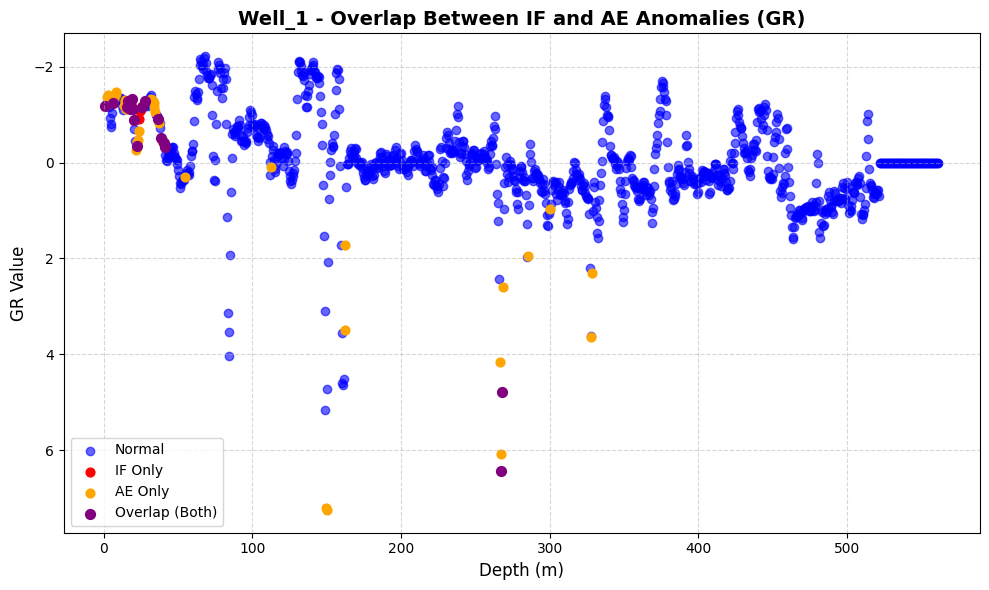

In [158]:


# Selecting one representative well
well_name = "Well_1"
df = wells_autoencoder[well_name]

# Selecting a representative feature to visualize
feature = "GR"  # You can change to 'RHOB', 'ILD', etc.

# Filter data by anomaly type
normal = df[(df['IF_Anomaly']==0) & (df['AE_Anomaly']==0)]
if_only = df[(df['IF_Anomaly']==1) & (df['AE_Anomaly']==0)]
ae_only = df[(df['IF_Anomaly']==0) & (df['AE_Anomaly']==1)]
overlap = df[(df['IF_Anomaly']==1) & (df['AE_Anomaly']==1)]

# Plot setup
plt.figure(figsize=(10, 6))
plt.scatter(normal['DEPT'], normal[feature], color='blue', alpha=0.6, label='Normal')
plt.scatter(if_only['DEPT'], if_only[feature], color='red', s=40, label='IF Only')
plt.scatter(ae_only['DEPT'], ae_only[feature], color='orange', s=40, label='AE Only')
plt.scatter(overlap['DEPT'], overlap[feature], color='purple', s=50, label='Overlap (Both)')

# Plot formatting
plt.gca().invert_yaxis()
plt.xlabel('Depth (m)', fontsize=12)
plt.ylabel(f'{feature} Value', fontsize=12)
plt.title(f'{well_name} - Overlap Between IF and AE Anomalies ({feature})', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Save plot
import os
output_folder = "plots/ReportFigures"
os.makedirs(output_folder, exist_ok=True)
save_path = os.path.join(output_folder, f"{well_name}_IF_AE_Overlap_{feature}.png")
plt.savefig(save_path, dpi=300)
plt.show()

